# ArtBench-10 Student Starter Pack

This notebook is a starting template for class projects using **ArtBench-10**.

It covers:

1. Loading ArtBench-10 from the local folder `artbench_generative_suite/ArtBench-10`
2. Exploring dataset shape and class distribution
3. Building PyTorch dataloaders
4. Visualizing samples in a grid
5. Exporting samples to image files (one image per file)
6. Loading subset definitions from `training.csv` generated by `generate_training_csv.py`


## Dataset quick notes

- **Domain**: paintings / artistic styles
- **Classes**: 10 styles
- **Image size**: 32x32 RGB
- **Splits**: train and test

In this project setup, dataset files are expected in:

- `ArtBench-10/artbench-10-python/artbench-10-batches-py/`
- `ArtBench-10/ArtBench-10.csv`

If you do not have it on the folder, download from kaggle directly:

https://www.kaggle.com/datasets/alexanderliao/artbench10


In [14]:
from __future__ import annotations

import sys
import random
from pathlib import Path
from collections import Counter

import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from torchvision.utils import make_grid, save_image
import matplotlib.pyplot as plt
import math

In [2]:
#Clemente
!git clone https://github.com/GustaTheCreator/IAG-TP1.git

Cloning into 'IAG-TP1'...
remote: Enumerating objects: 1019, done.
remote: Counting objects: 100% (1019/1019), done.
remote: Compressing objects: 100% (1013/1013), done.
remote: Total 1019 (delta 20), reused 995 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (1019/1019), 36.28 MiB | 26.24 MiB/s, done.
Resolving deltas: 100% (20/20), done.


In [3]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

import os

# Resolve project root robustly from current working directory
def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    roots_to_check = [cwd, cwd.parent, cwd.parent.parent]
    for root in roots_to_check:
        if (root / 'scripts' / 'artbench_local_dataset.py').exists():
            return root

    # Also handle case where kernel starts from a parent folder of the repository
    for child in cwd.iterdir():
        if child.is_dir() and (child / 'scripts' / 'artbench_local_dataset.py').exists():
            return child

    raise FileNotFoundError(
        'Could not find scripts/artbench_local_dataset.py. '
        'Open the notebook from student_start_pack/ inside the class repository.'
    )


def resolve_kaggle_root(project_root: Path) -> Path:
    env_path = os.getenv('ARTBENCH10_ROOT', '').strip()
    candidates = []
    if env_path:
        candidates.append(Path(env_path).expanduser().resolve())

    candidates.extend([
        project_root / 'ArtBench-10',
        project_root.parent / 'ArtBench-10',
        project_root / 'student_start_pack' / 'ArtBench-10',
    ])

    for c in candidates:
        if c.exists():
            return c

    # Keep a sensible default path; the loader in scripts/artbench_local_dataset.py
    # will perform strict structure checks and raise clear errors if needed.
    return project_root / 'ArtBench-10'


PROJECT_ROOT = resolve_project_root()
SCRIPTS_DIR = PROJECT_ROOT / 'scripts'
KAGGLE_ROOT = resolve_kaggle_root(PROJECT_ROOT)

if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

print('PROJECT_ROOT =', PROJECT_ROOT)
print('KAGGLE_ROOT  =', KAGGLE_ROOT)
print('KAGGLE_ROOT exists =', KAGGLE_ROOT.exists())

PROJECT_ROOT = /content/IAG-TP1
KAGGLE_ROOT  = /content/IAG-TP1/ArtBench-10
KAGGLE_ROOT exists = False


In [4]:
# Uses your existing project helper in scripts/artbench_local_dataset.py
from artbench_local_dataset import resolve_dataset_splits

DATASET_SOURCE = os.getenv('ARTBENCH10_SOURCE', 'auto').strip().lower()
HF_DATASET_ID = os.getenv('ARTBENCH10_HF_DATASET_ID', 'zguo0525/ArtBench')

has_local_kaggle = (
    (KAGGLE_ROOT / 'ArtBench-10.csv').exists()
    and (KAGGLE_ROOT / 'artbench-10-python' / 'artbench-10-batches-py').exists()
)

if DATASET_SOURCE == 'auto':
    effective_source = 'kaggle' if has_local_kaggle else 'hf'
else:
    effective_source = DATASET_SOURCE

print('Requested source :', DATASET_SOURCE)
print('Effective source :', effective_source)

hf_ds = resolve_dataset_splits(
    dataset_id=HF_DATASET_ID,
    seed=SEED,
    dataset_source=effective_source,
    kaggle_root=KAGGLE_ROOT,
    default_source='hf',
)
train_hf = hf_ds['train']

print('Train size:', len(train_hf))
print('Columns   :', train_hf.column_names)

label_feature = train_hf.features['label']
class_names = list(label_feature.names)
num_classes = len(class_names)
print('Num classes:', num_classes)
print('Class names:', class_names)

Requested source : auto
Effective source : hf


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/721 [00:00<?, ?B/s]

data/train-00000-of-00004.parquet:   0%|          | 0.00/418M [00:00<?, ?B/s]

data/train-00001-of-00004.parquet:   0%|          | 0.00/408M [00:00<?, ?B/s]

...

data/train-00003-of-00004.parquet:   0%|          | 0.00/406M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/323M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Dataset source: hf dataset_id='zguo0525/ArtBench'
Train size: 50000
Columns   : ['image', 'label']
Num classes: 10
Class names: ['expressionism', 'art_nouveau', 'renaissance', 'ukiyo_e', 'realism', 'romanticism', 'surrealism', 'impressionism', 'baroque', 'post_impressionism']


In [5]:
# Class distribution summary
train_counts = Counter(train_hf["label"])

print("\nTrain class distribution:")
for cid, name in enumerate(class_names):
    print(f"  {cid:2d} | {name:>15s} | {train_counts.get(cid, 0):6d}")


Train class distribution:
   0 |   expressionism |   5000
   1 |     art_nouveau |   5000
   2 |     renaissance |   5000
   3 |         ukiyo_e |   5000
   4 |         realism |   5000
   5 |     romanticism |   5000
   6 |      surrealism |   5000
   7 |   impressionism |   5000
   8 |         baroque |   5000
   9 | post_impressionism |   5000


## Build PyTorch datasets and dataloaders

You can change:

- `IMAGE_SIZE` (default 32)
- `BATCH_SIZE`
- `TRAIN_FRACTION` if you want to train on a subset

In [6]:
IMAGE_SIZE = 32
BATCH_SIZE = 64
NUM_WORKERS = 2

def safe_num_workers(requested: int) -> int:
    # Avoid notebook multiprocessing pickling issues on macOS/ipykernel.
    if "ipykernel" in sys.modules and int(requested) > 0:
        print("Notebook kernel detected: forcing num_workers=0 for DataLoader stability.")
        return 0
    return int(requested)

EFFECTIVE_NUM_WORKERS = safe_num_workers(NUM_WORKERS)
TRAIN_FRACTION = 1.0  # Example: 0.5 means half of train split

transform = T.Compose([
    T.Resize(IMAGE_SIZE, interpolation=T.InterpolationMode.BILINEAR),
    T.CenterCrop(IMAGE_SIZE),
    T.ToTensor(),  # outputs [0,1]
])


class HFDatasetTorch(Dataset):
    def __init__(self, hf_split, transform=None, indices=None):
        self.ds = hf_split
        self.transform = transform
        self.indices = list(range(len(hf_split))) if indices is None else list(indices)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        ex = self.ds[real_idx]
        img = ex["image"]
        y = int(ex["label"])
        x = self.transform(img) if self.transform else img
        return x, y, real_idx


def make_subset_indices(n_total: int, fraction: float, seed: int = 42):
    n_keep = max(1, int(round(n_total * fraction)))
    g = np.random.RandomState(seed)
    idx = np.arange(n_total)
    g.shuffle(idx)
    return idx[:n_keep].tolist()


train_indices = make_subset_indices(len(train_hf), TRAIN_FRACTION, seed=SEED)

train_ds = HFDatasetTorch(train_hf, transform=transform, indices=train_indices)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=EFFECTIVE_NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print("Train dataset length (after fraction):", len(train_ds))
print("Train batches                        :", len(train_loader))

Notebook kernel detected: forcing num_workers=0 for DataLoader stability.
Train dataset length (after fraction): 50000
Train batches                        : 782


## Load subset of 20% samples `training_20_percent.csv`

you can reproduce the same subset in this notebook by loading IDs from that CSV.

Use `train_id_original` for indexing this notebook's full train split.


In [7]:
import csv

#warning if using colab kernel on vscode you need to put the files on your google drive and link this notebook to it.
TRAINING_CSV_PATH = PROJECT_ROOT / 'student_start_pack' / 'training_20_percent.csv'
INDEX_COLUMN = 'train_id_original'  # recommended


def load_ids_from_training_csv(csv_path: Path, index_column: str = "train_id_original") -> list[int]:
    csv_path = Path(csv_path)
    if not csv_path.exists():
        raise FileNotFoundError(
            f"training.csv not found: {csv_path}\n"
            "Generate it first with scripts/generate_training_csv.py"
        )

    ids = []
    with open(csv_path, 'r', encoding='utf-8', newline='') as f:
        r = csv.DictReader(f)
        if index_column not in (r.fieldnames or []):
            raise ValueError(
                f"Column {index_column!r} not present in {csv_path}. "
                f"Available: {r.fieldnames}"
            )
        for row in r:
            v = str(row.get(index_column, "")).strip()
            if v == "":
                continue
            ids.append(int(v))

    if len(ids) == 0:
        raise ValueError(f"No ids found in {csv_path} column {index_column!r}")
    return ids


train_ids_from_csv = load_ids_from_training_csv(TRAINING_CSV_PATH, index_column=INDEX_COLUMN)
print('Loaded ids:', len(train_ids_from_csv))
print('First 10 ids:', train_ids_from_csv[:10])

# Build a train dataset/loader using exactly those IDs
train_ds_from_csv = HFDatasetTorch(train_hf, transform=transform, indices=train_ids_from_csv)
train_loader_from_csv = DataLoader(
    train_ds_from_csv,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=EFFECTIVE_NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print('Subset train dataset length:', len(train_ds_from_csv))
print('Subset train batches      :', len(train_loader_from_csv))


Loaded ids: 10000
First 10 ids: [33553, 9427, 199, 12447, 39489, 42724, 10822, 49498, 4144, 36958]
Subset train dataset length: 10000
Subset train batches      : 157


## Visualize a sample grid

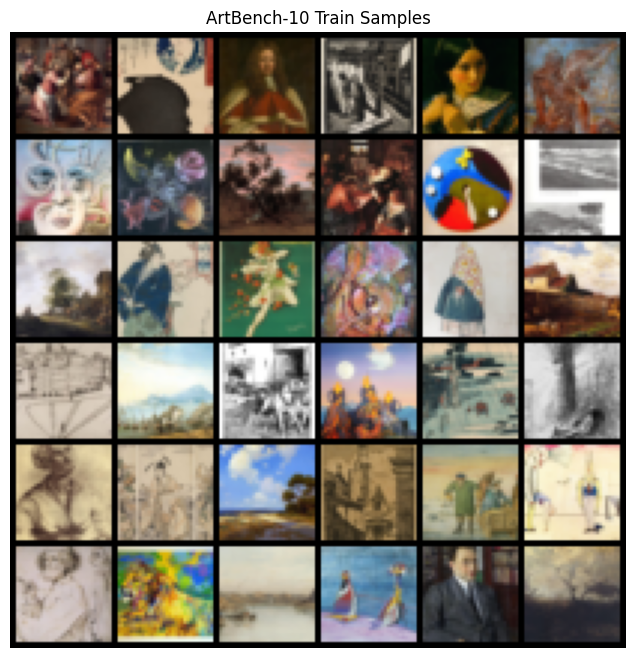

Labels: ['renaissance', 'ukiyo_e', 'baroque', 'expressionism', 'romanticism', 'surrealism', 'surrealism', 'expressionism', 'romanticism', 'renaissance', 'surrealism', 'art_nouveau', 'baroque', 'ukiyo_e', 'art_nouveau', 'surrealism', 'art_nouveau', 'impressionism', 'expressionism', 'romanticism', 'romanticism', 'surrealism', 'ukiyo_e', 'impressionism', 'renaissance', 'ukiyo_e', 'impressionism', 'realism', 'baroque', 'surrealism', 'renaissance', 'impressionism', 'impressionism', 'surrealism', 'realism', 'realism']


In [8]:
def show_batch_grid(loader, class_names, n_images=36, nrow=6, title='Sample Grid'):
    x, y, idx = next(iter(loader))
    x = x[:n_images]
    y = y[:n_images]

    grid = make_grid(x, nrow=nrow, padding=2)
    np_img = grid.permute(1, 2, 0).cpu().numpy()

    plt.figure(figsize=(8, 8))
    plt.imshow(np_img)
    plt.axis('off')
    plt.title(title)
    plt.show()

    # Print labels for quick inspection
    labels_str = [class_names[int(v)] for v in y]
    print('Labels:', labels_str)


show_batch_grid(train_loader, class_names, n_images=36, nrow=6, title='ArtBench-10 Train Samples')

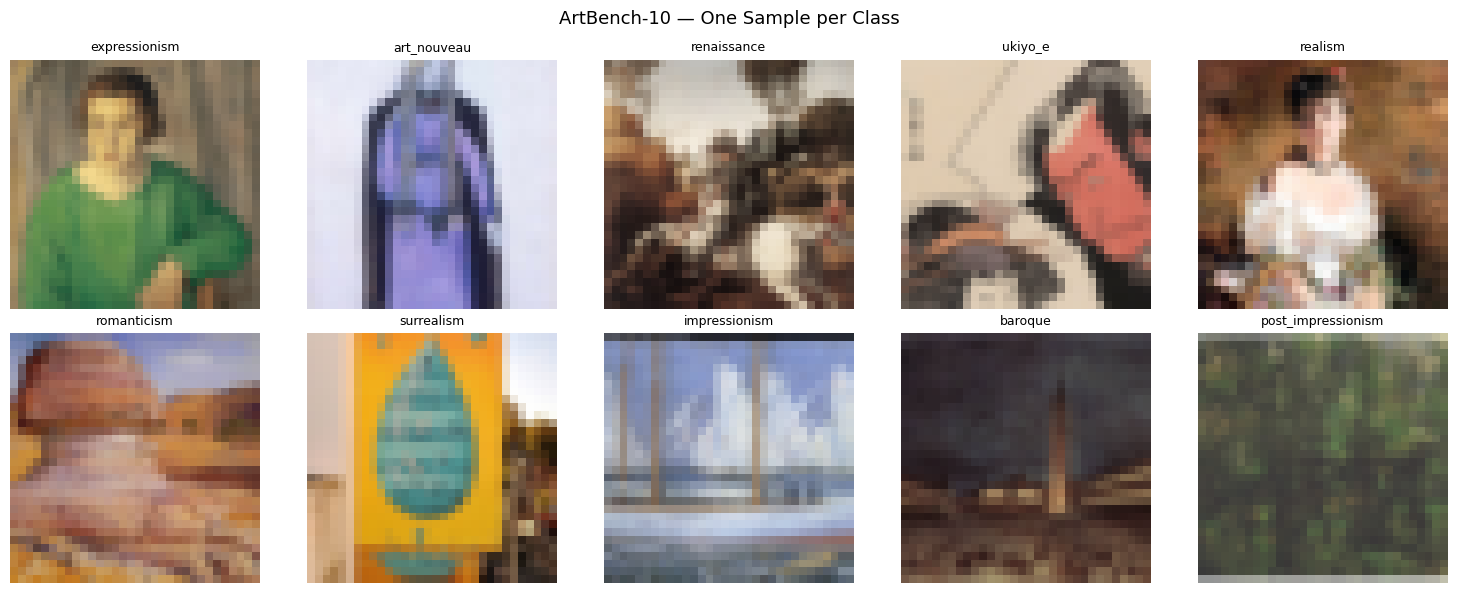

In [9]:
def show_one_per_class(dataset, class_names, title='One Sample per Class'):
    all_labels = np.array([dataset[i][1] for i in range(len(dataset))])

    num_classes = len(class_names)
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.flatten()

    for i in range(num_classes):
        matches = np.where(all_labels == i)[0]
        if len(matches) == 0:
            axes[i].axis('off')
            axes[i].set_title(f'Class {i}\n(missing)')
            continue

        img, label, *_ = dataset[matches[0]]
        img_np = img.permute(1, 2, 0).cpu().numpy()
        img_np = np.clip(img_np, 0, 1)

        axes[i].imshow(img_np)
        axes[i].set_title(class_names[int(label)], fontsize=9)
        axes[i].axis('off')

    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()


show_one_per_class(train_ds_from_csv, class_names, title='ArtBench-10 — One Sample per Class')

## Export samples to image files

This helper saves one PNG per sample and writes a CSV with metadata.
Useful for qualitative analysis or external metric tools.

In [ ]:
import csv


def export_split_to_folder(
    loader: DataLoader,
    class_names: list[str],
    out_dir: Path,
    max_images: int | None = 500,
):
    out_dir = Path(out_dir)
    img_dir = out_dir / 'images'
    img_dir.mkdir(parents=True, exist_ok=True)

    rows = []
    saved = 0

    for x, y, idx in loader:
        b = x.shape[0]
        for i in range(b):
            if max_images is not None and saved >= max_images:
                break

            label_id = int(y[i].item())
            label_name = class_names[label_id]
            src_idx = int(idx[i].item())

            file_name = f"img_{saved:06d}_label{label_id:02d}_idx{src_idx:06d}.png"
            path = img_dir / file_name
            save_image(x[i], path)

            rows.append({
                'file_name': file_name,
                'label_id': label_id,
                'label_name': label_name,
                'source_index': src_idx,
            })
            saved += 1

        if max_images is not None and saved >= max_images:
            break

    csv_path = out_dir / 'metadata.csv'
    with open(csv_path, 'w', encoding='utf-8', newline='') as f:
        w = csv.DictWriter(f, fieldnames=['file_name', 'label_id', 'label_name', 'source_index'])
        w.writeheader()
        w.writerows(rows)

    print(f'Exported {saved} images to: {img_dir}')
    print(f'Metadata CSV: {csv_path}')


EXPORT_ROOT = Path('exported_data')
EXPORT_ROOT.mkdir(parents=True, exist_ok=True)

export_split_to_folder(train_loader, class_names, EXPORT_ROOT / 'train_subset', max_images=500)


Exported 500 images to: exported_data/train_subset/images
Metadata CSV: exported_data/train_subset/metadata.csv


## TODO - ArtBench Project 1 (Roadmap)

### Status update (done in notebook)
- [x] Dataset loading and subset loaders
- [x] Modular training stack foundation (config, run dirs, seed control, JSON reports)
- [x] VAE model family implemented and trained (dev run)
- [x] DCGAN model family implemented and trained (dev run)
- [x] Diffusion model family implemented and trained (dev run)
- [x] Shared sampling/export path for all model families
- [x] Shared FID/KID evaluation functions implemented
- [x] Smoke-test evaluation executed for all families
- [x] Environment lock file generated (`requirements_lock.txt`)

### Remaining mandatory execution tasks
- [ ] Run official protocol with **5000 generated** and **5000 real** per model
- [ ] Run **10-seed** evaluation and report **mean +- std** for FID/KID
- [ ] Select best-performing model after official evaluation
- [ ] Retrain selected model on full 50k training split (long run)
- [ ] Re-run official 10-seed evaluation for final selected model

### Report and submission
- [ ] Write LNCS report (max 12 pages, excluding references)
- [ ] Include architecture choices, hyperparameters, seeds, and reproducibility details
- [ ] Include qualitative grids + quantitative tables
- [ ] Add explicit acknowledgment of AI tools and external sources
- [ ] Confirm final deadline on official channel and submit via Inforestudante

## Implementation Start - Modular Training Stack (VAE Baseline)

This section starts the TODO implementation with reusable functions and no duplicated training code.
The same utilities can later be reused for DCGAN and Diffusion models.

In [10]:
import json
import time
from dataclasses import dataclass, asdict

import torch.nn as nn
import torch.nn.functional as F
from torch import optim


@dataclass
class TrainConfig:
    run_name: str = 'vae_baseline_dev'
    seed: int = 42
    batch_size: int = 64
    epochs: int = 3
    lr: float = 2e-4
    beta_kl: float = 1.0
    latent_dim: int = 128
    use_csv_subset: bool = True
    max_train_steps_per_epoch: int | None = 200  # fast dev default


def set_global_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def get_device() -> torch.device:
    return torch.device('cuda' if torch.cuda.is_available() else 'cpu')


def get_active_train_loader(use_csv_subset: bool) -> DataLoader:
    return train_loader_from_csv if use_csv_subset else train_loader


def make_run_dir(base_dir: Path, run_name: str) -> Path:
    ts = time.strftime('%Y%m%d_%H%M%S')
    out_dir = base_dir / f'{run_name}_{ts}'
    out_dir.mkdir(parents=True, exist_ok=True)
    return out_dir


def save_json(path: Path, payload: dict) -> None:
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(payload, f, indent=2, ensure_ascii=True)


ARTIFACTS_ROOT = Path('artifacts')
ARTIFACTS_ROOT.mkdir(parents=True, exist_ok=True)

cfg = TrainConfig()
set_global_seed(cfg.seed)
device = get_device()

print('Device:', device)
print('Using CSV subset loader:', cfg.use_csv_subset)

Device: cuda
Using CSV subset loader: True


In [11]:
class ConvVAE(nn.Module):
    def __init__(self, latent_dim: int = 128):
        super().__init__()
        self.latent_dim = latent_dim

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1),  # 16x16
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),  # 8x8
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),  # 4x4
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
        )
        self.flatten_dim = 128 * 4 * 4
        self.fc_mu = nn.Linear(self.flatten_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.flatten_dim, latent_dim)

        self.fc_decode = nn.Linear(latent_dim, self.flatten_dim)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),  # 8x8
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),   # 16x16
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1),    # 32x32
            nn.Sigmoid(),
        )

    def encode(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        h = self.encoder(x).view(x.size(0), -1)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z: torch.Tensor) -> torch.Tensor:
        h = self.fc_decode(z).view(z.size(0), 128, 4, 4)
        return self.decoder(h)

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar


def vae_loss(x: torch.Tensor, recon: torch.Tensor, mu: torch.Tensor, logvar: torch.Tensor, beta_kl: float) -> tuple[torch.Tensor, dict]:
    recon = recon.clamp(1e-6, 1.0 - 1e-6)
    recon_loss = F.binary_cross_entropy(recon, x, reduction='mean')
    kl_loss = -0.5 * torch.mean(torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1))
    total = recon_loss + beta_kl * kl_loss
    return total, {
        'loss_total': float(total.detach().cpu().item()),
        'loss_recon': float(recon_loss.detach().cpu().item()),
        'loss_kl': float(kl_loss.detach().cpu().item()),
    }


def train_one_epoch_vae(
    model: ConvVAE,
    loader: DataLoader,
    optimizer: optim.Optimizer,
    device: torch.device,
    beta_kl: float,
    max_steps: int | None = None,
) -> dict:
    model.train()
    sums = {'loss_total': 0.0, 'loss_recon': 0.0, 'loss_kl': 0.0}
    steps = 0

    for batch_idx, (x, _, _) in enumerate(loader):
        x = x.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        recon, mu, logvar = model(x)
        loss, metrics = vae_loss(x, recon, mu, logvar, beta_kl=beta_kl)
        loss.backward()
        optimizer.step()

        for k in sums:
            sums[k] += metrics[k]
        steps += 1

        if max_steps is not None and steps >= max_steps:
            break

    if steps == 0:
        raise RuntimeError('No training steps were executed.')

    return {k: v / steps for k, v in sums.items()}


@torch.no_grad()
def generate_vae_samples(model: ConvVAE, n_samples: int, device: torch.device, batch_size: int = 256) -> torch.Tensor:
    model.eval()
    out = []
    generated = 0

    while generated < n_samples:
        cur_bs = min(batch_size, n_samples - generated)
        z = torch.randn(cur_bs, model.latent_dim, device=device)
        x = model.decode(z).clamp(0.0, 1.0).cpu()
        out.append(x)
        generated += cur_bs

    return torch.cat(out, dim=0)

In [ ]:
def run_vae_experiment(cfg: TrainConfig) -> dict:
    set_global_seed(cfg.seed)
    device = get_device()
    loader = get_active_train_loader(cfg.use_csv_subset)
    run_dir = make_run_dir(ARTIFACTS_ROOT, cfg.run_name)

    model = ConvVAE(latent_dim=cfg.latent_dim).to(device)
    optimizer = optim.Adam(model.parameters(), lr=cfg.lr)

    history = []
    for epoch in range(1, cfg.epochs + 1):
        metrics = train_one_epoch_vae(
            model=model,
            loader=loader,
            optimizer=optimizer,
            device=device,
            beta_kl=cfg.beta_kl,
            max_steps=cfg.max_train_steps_per_epoch,
        )
        metrics['epoch'] = epoch
        history.append(metrics)
        print(
            f"[VAE][Epoch {epoch:02d}] "
            f"loss={metrics['loss_total']:.4f} "
            f"recon={metrics['loss_recon']:.4f} "
            f"kl={metrics['loss_kl']:.4f}"
        )

    ckpt_path = run_dir / 'vae.pt'
    torch.save(model.state_dict(), ckpt_path)

    samples = generate_vae_samples(model, n_samples=64, device=device, batch_size=64)
    preview_path = run_dir / 'samples_grid.png'
    save_image(make_grid(samples, nrow=8, padding=2), preview_path)

    report = {
        'config': asdict(cfg),
        'history': history,
        'checkpoint_path': str(ckpt_path),
        'preview_grid_path': str(preview_path),
    }
    save_json(run_dir / 'train_report.json', report)

    print('Saved checkpoint:', ckpt_path)
    print('Saved preview grid:', preview_path)
    return report


vae_report = run_vae_experiment(cfg)

[VAE][Epoch 01] loss=2.0088 recon=0.6935 kl=1.3153
[VAE][Epoch 02] loss=0.8144 recon=0.6857 kl=0.1287
[VAE][Epoch 03] loss=0.7563 recon=0.6850 kl=0.0713
Saved checkpoint: artifacts/vae_baseline_dev_20260327_102831/vae.pt
Saved preview grid: artifacts/vae_baseline_dev_20260327_102831/samples_grid.png


#### Clemente Version

In [ ]:
import json
import time
from dataclasses import dataclass, asdict

import torch.nn as nn
import torch.nn.functional as F
from torch import optim

In [ ]:
# ── Hyperparameters ────────────────────────────────────────────────────────────
LATENT_DIM  = 32
VAE_EPOCHS  = 50
VAE_LR      = 1e-3

# ── Model ─────────────────────────────────────────────────────────────────────
# Encoder/decoder sized for IMAGE_SIZE=32:
#   32 → 16 → 8 → 4  (3 stride-2 convolutions)

class VAE(nn.Module):
    def __init__(self, latent_dim: int = LATENT_DIM, image_size: int = IMAGE_SIZE):
        super().__init__()
        self.latent_dim = latent_dim

        # Spatial size after 3 stride-2 convolutions
        self.feat_size = image_size // 8          # 32 // 8 = 4
        self.flat_dim  = 128 * self.feat_size ** 2  # 128 * 16 = 2048

        # ── Encoder ───────────────────────────────────────────────────────────
        self.encoder = nn.Sequential(
            nn.Conv2d(3,   32,  kernel_size=4, stride=2, padding=1),  # 32→16
            nn.ReLU(),
            nn.Conv2d(32,  64,  kernel_size=4, stride=2, padding=1),  # 16→8
            nn.ReLU(),
            nn.Conv2d(64,  128, kernel_size=4, stride=2, padding=1),  # 8→4
            nn.ReLU(),
            nn.Flatten(),
        )
        self.fc_mu     = nn.Linear(self.flat_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.flat_dim, latent_dim)

        # ── Decoder ───────────────────────────────────────────────────────────
        self.decoder_input = nn.Linear(latent_dim, self.flat_dim)
        self.decoder = nn.Sequential(
            nn.Unflatten(1, (128, self.feat_size, self.feat_size)),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),  # 4→8
            nn.ReLU(),
            nn.ConvTranspose2d(64,  32, kernel_size=4, stride=2, padding=1),  # 8→16
            nn.ReLU(),
            nn.ConvTranspose2d(32,   3, kernel_size=4, stride=2, padding=1),  # 16→32
            nn.Tanh(),
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + std * torch.randn_like(std)

    def decode(self, z):
        return self.decoder(self.decoder_input(z))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


# ── Loss ──────────────────────────────────────────────────────────────────────
def vae_loss(recon_x, x, mu, logvar):
    recon_loss = nn.functional.mse_loss(recon_x, x, reduction='sum')
    kl_div     = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_div

In [ ]:
# ── Training loop ─────────────────────────────────────────────────────────────
def train_vae(vae, loader, optimizer, num_epochs: int = VAE_EPOCHS):
    vae.train()
    for epoch in range(1, num_epochs + 1):
        total_loss = 0.0
        for x, *_ in loader:           # tolerates (img,), (img, label), (img, label, idx)
            x = x.to(DEVICE)
            optimizer.zero_grad()
            recon_x, mu, logvar = vae(x)
            loss = vae_loss(recon_x, x, mu, logvar)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch:>3}/{num_epochs}  loss: {total_loss / len(loader.dataset):.4f}")


# ── Init & run ────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

vae       = VAE(latent_dim=LATENT_DIM, image_size=IMAGE_SIZE).to(DEVICE)
optimizer = torch.optim.Adam(vae.parameters(), lr=VAE_LR)

# print(vae)
train_vae(vae, train_loader_from_csv, optimizer, num_epochs=VAE_EPOCHS)

Epoch   1/50  loss: 150.3106
Epoch   2/50  loss: 84.0952
Epoch   3/50  loss: 76.6200
Epoch   4/50  loss: 73.8393
Epoch   5/50  loss: 71.1609
Epoch   6/50  loss: 68.6813
Epoch   7/50  loss: 67.7648
Epoch   8/50  loss: 66.7645
Epoch   9/50  loss: 66.4077
Epoch  10/50  loss: 65.8739
Epoch  11/50  loss: 65.8405
Epoch  12/50  loss: 65.2683
Epoch  13/50  loss: 65.0181
Epoch  14/50  loss: 64.9997
Epoch  15/50  loss: 64.7970
Epoch  16/50  loss: 64.6533
Epoch  17/50  loss: 64.4486
Epoch  18/50  loss: 64.4498
Epoch  19/50  loss: 63.9923
Epoch  20/50  loss: 63.9611
Epoch  21/50  loss: 63.8692
Epoch  22/50  loss: 63.9077
Epoch  23/50  loss: 63.6615
Epoch  24/50  loss: 63.6170
Epoch  25/50  loss: 63.4544
Epoch  26/50  loss: 63.2358
Epoch  27/50  loss: 63.3889
Epoch  28/50  loss: 63.1379
Epoch  29/50  loss: 63.0938
Epoch  30/50  loss: 63.1429
Epoch  31/50  loss: 62.9512
Epoch  32/50  loss: 63.0034
Epoch  33/50  loss: 62.8726
Epoch  34/50  loss: 62.9087
Epoch  35/50  loss: 62.8197
Epoch  36/50  loss:

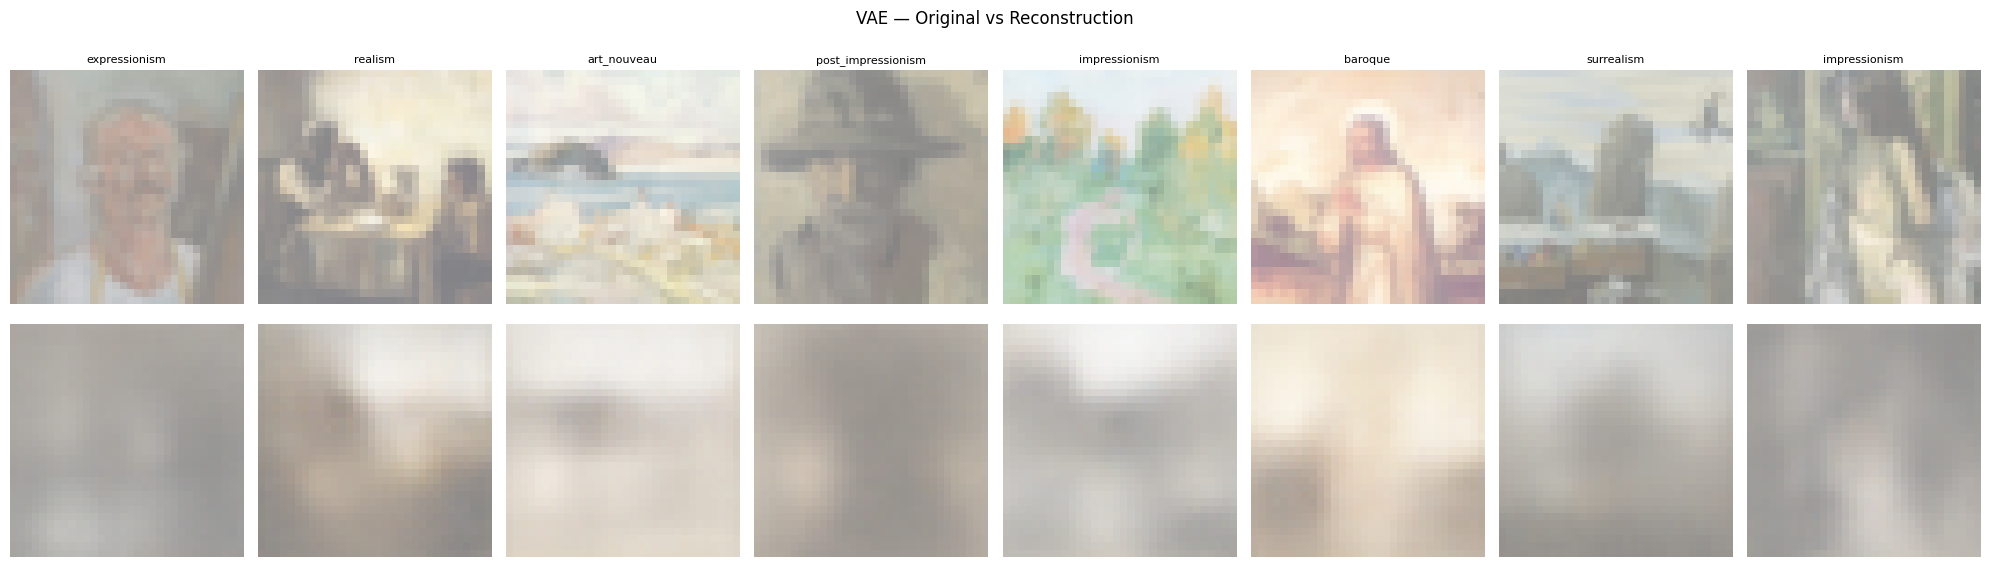

In [ ]:
# ── Visualize original vs reconstruction ─────────────────────────────────────
def show_reconstructions(vae, loader, class_names, n=8, seed=None):
    vae.eval()

    if seed is not None:
        # Build a temporary loader with a fixed generator so the same batch always appears
        g = torch.Generator()
        g.manual_seed(seed)
        fixed_loader = DataLoader(
            loader.dataset,
            batch_size=loader.batch_size,
            shuffle=True,
            generator=g,
            num_workers=0,
            pin_memory=False,
        )
        batch = next(iter(fixed_loader))
    else:
        batch = next(iter(loader))

    x, labels, *_ = batch
    with torch.no_grad():
        x = x[:n].to(DEVICE)
        recon, _, _ = vae(x)

    def denorm(t):
        return (t.cpu().clamp(-1, 1) + 1) / 2

    x_np     = denorm(x)
    recon_np = denorm(recon)

    fig, axes = plt.subplots(2, n, figsize=(2.5 * n, 6))
    for i in range(n):
        for row, img in enumerate([x_np[i], recon_np[i]]):
            axes[row, i].imshow(img.permute(1, 2, 0).numpy())
            axes[row, i].axis('off')
            if row == 0:
                axes[row, i].set_title(class_names[int(labels[i])], fontsize=8)

    axes[0, 0].set_ylabel('Original',      fontsize=9)
    axes[1, 0].set_ylabel('Reconstructed', fontsize=9)
    plt.suptitle('VAE — Original vs Reconstruction', fontsize=12)
    plt.tight_layout()
    plt.show()

show_reconstructions(vae, train_loader_from_csv, class_names, seed=42)

Epoch   1/50  loss: 155.3681  lr: 0.001000
Epoch   2/50  loss: 85.5315  lr: 0.001000
Epoch   3/50  loss: 78.0092  lr: 0.001000
Epoch   4/50  loss: 75.5447  lr: 0.001000
Epoch   5/50  loss: 73.4774  lr: 0.001000
Epoch   6/50  loss: 72.3178  lr: 0.001000
Epoch   7/50  loss: 71.5414  lr: 0.001000
Epoch   8/50  loss: 69.3413  lr: 0.001000
Epoch   9/50  loss: 67.6867  lr: 0.001000
Epoch  10/50  loss: 67.0311  lr: 0.001000
Epoch  11/50  loss: 66.4425  lr: 0.001000
Epoch  12/50  loss: 66.2228  lr: 0.001000
Epoch  13/50  loss: 65.4687  lr: 0.001000
Epoch  14/50  loss: 65.0160  lr: 0.001000
Epoch  15/50  loss: 64.8469  lr: 0.001000
Epoch  16/50  loss: 64.5594  lr: 0.001000
Epoch  17/50  loss: 64.5163  lr: 0.001000
Epoch  18/50  loss: 64.0962  lr: 0.001000
Epoch  19/50  loss: 64.1071  lr: 0.001000
Epoch  20/50  loss: 63.9788  lr: 0.001000
Epoch  21/50  loss: 63.9276  lr: 0.001000
Epoch  22/50  loss: 63.6169  lr: 0.001000
Epoch  23/50  loss: 63.5797  lr: 0.001000
Epoch  24/50  loss: 63.4871  lr: 

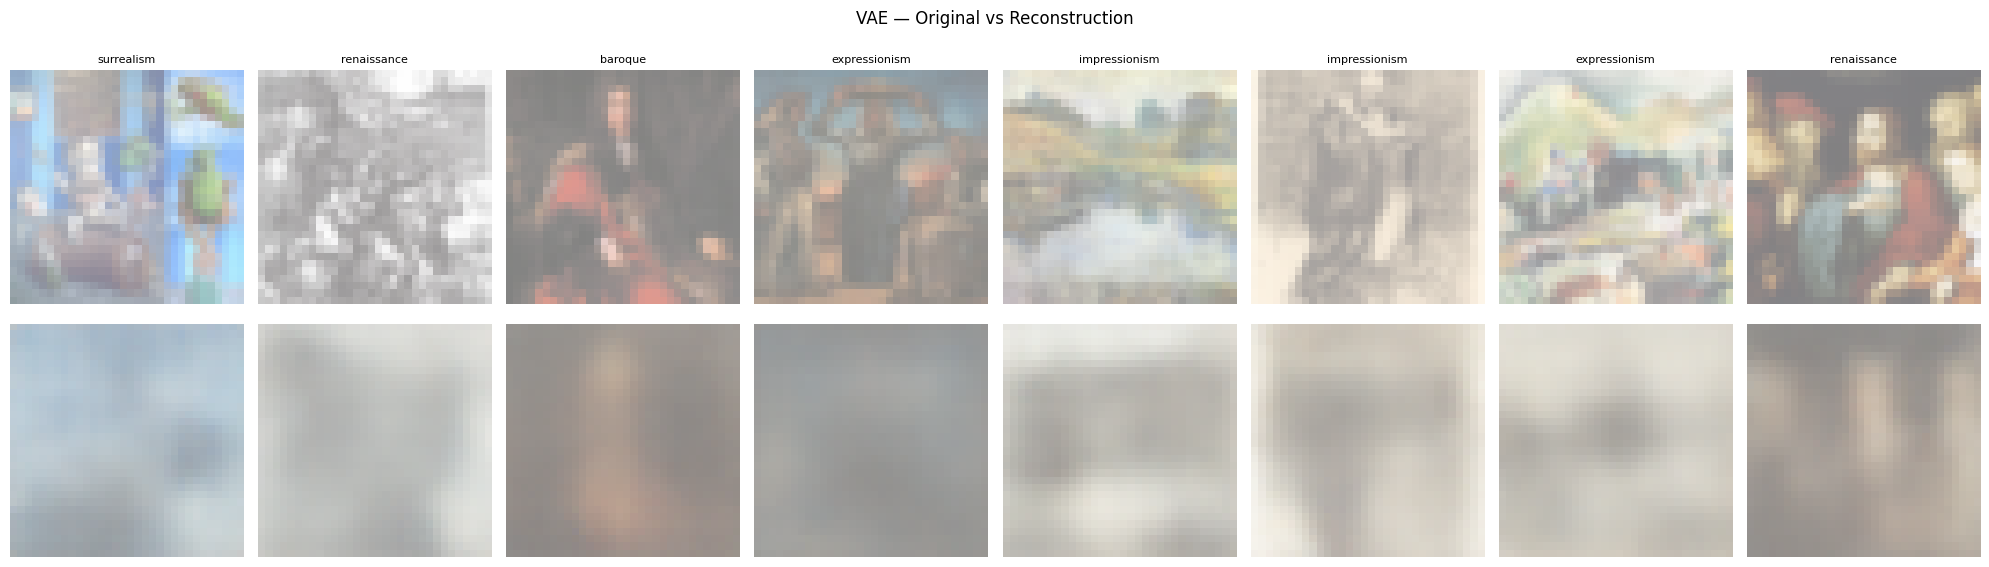

In [ ]:
#test 2 with scheduler

# ── Training loop with scheduler ──────────────────────────────────────────────
def train_vae2(vae, loader, optimizer, num_epochs: int = VAE_EPOCHS):
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5
    )

    vae.train()
    for epoch in range(1, num_epochs + 1):
        total_loss = 0.0
        for x, *_ in loader:
            x = x.to(DEVICE)
            optimizer.zero_grad()
            recon_x, mu, logvar = vae(x)
            loss = vae_loss(recon_x, x, mu, logvar)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(loader.dataset)
        scheduler.step(avg_loss)   # <-- feed current loss; scheduler decides if LR should drop
        print(f"Epoch {epoch:>3}/{num_epochs}  loss: {avg_loss:.4f}  lr: {optimizer.param_groups[0]['lr']:.6f}")



# ── Init & run ────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

vae2       = VAE(latent_dim=LATENT_DIM, image_size=IMAGE_SIZE).to(DEVICE)
optimizer = torch.optim.Adam(vae2.parameters(), lr=VAE_LR)

# print(vae2)
train_vae2(vae2, train_loader_from_csv, optimizer, num_epochs=VAE_EPOCHS)


show_reconstructions(vae2, train_loader_from_csv, class_names, seed=42)

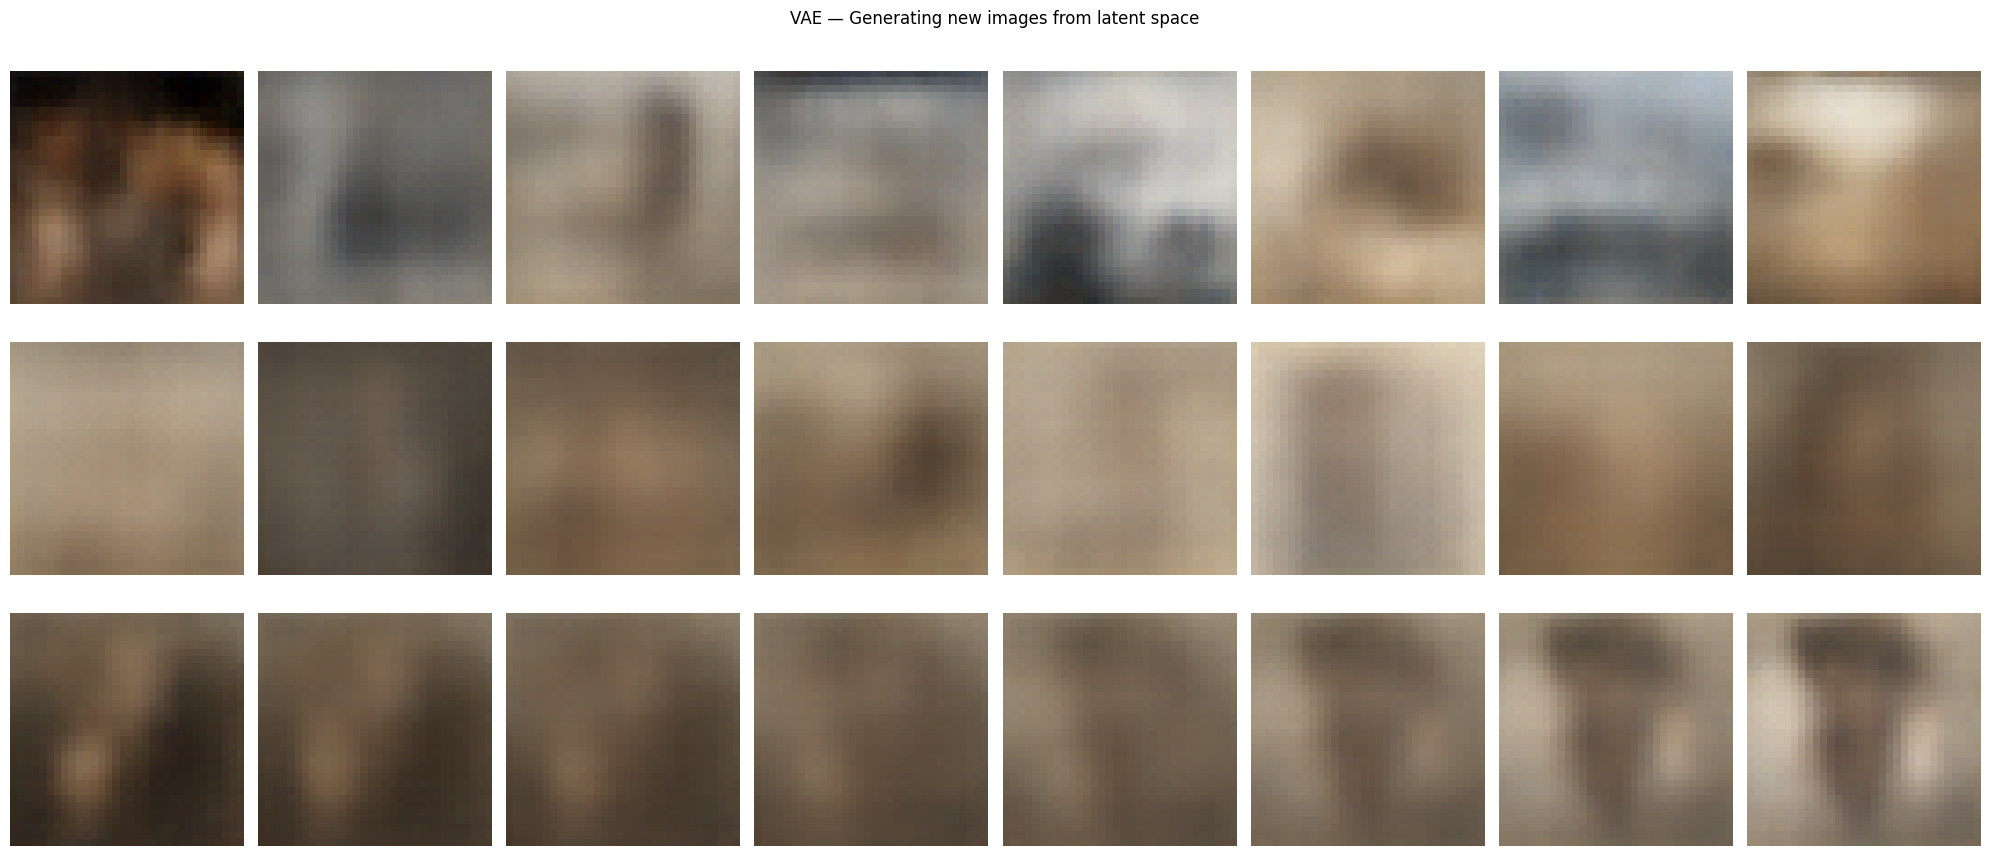

In [ ]:
def generate_vae_new_images(model, n=8, device=DEVICE, seed=None):
    model.eval()
    if seed is not None:
        torch.manual_seed(seed)

    with torch.no_grad():

        # ── Method 1: Pure random sample (standard normal) ────────────────────
        # Sample z ~ N(0, I) — the "default" way, no control
        z_random = torch.randn(n, model.latent_dim, device=device)
        imgs_random = model.decode(z_random).clamp(0, 1).cpu()

        # ── Method 2: Control mean and variance manually ──────────────────────
        # Sample z ~ N(mu, std) where YOU choose mu and std
        # mu  shifts the "style" (move through latent space)
        # std controls diversity (higher = more varied/chaotic output)
        mu  = torch.zeros(n, model.latent_dim, device=device)   # change this
        std = torch.ones(n, model.latent_dim, device=device) * 0.5  # tighter than default
        z_controlled = mu + std * torch.randn_like(std)
        imgs_controlled = model.decode(z_controlled).clamp(0, 1).cpu()

        # ── Method 3: Interpolate between two random points ───────────────────
        # Walk a straight line in latent space between z_a and z_b
        # Each image is a blend — useful to see if the space is smooth
        z_a = torch.randn(1, model.latent_dim, device=device).expand(n, -1)
        z_b = torch.randn(1, model.latent_dim, device=device).expand(n, -1)
        alphas = torch.linspace(0, 1, n, device=device).unsqueeze(1)
        z_interp = (1 - alphas) * z_a + alphas * z_b
        imgs_interp = model.decode(z_interp).clamp(0, 1).cpu()

    # ── Plot all three rows ───────────────────────────────────────────────────
    all_rows   = [imgs_random, imgs_controlled, imgs_interp]
    row_labels = ['Random z ~ N(0,1)', 'Controlled z ~ N(0, 0.5)', 'Interpolation A→B']

    fig, axes = plt.subplots(3, n, figsize=(2.5 * n, 9))
    for row, (imgs, label) in enumerate(zip(all_rows, row_labels)):
        for i in range(n):
            axes[row, i].imshow(imgs[i].permute(1, 2, 0).numpy())
            axes[row, i].axis('off')
        axes[row, 0].set_ylabel(label, fontsize=9)

    plt.suptitle('VAE — Generating new images from latent space', fontsize=12)
    plt.tight_layout()
    plt.show()


generate_vae_new_images(vae, n=8,seed=42)

## DCGAN (Modular)

In [ ]:
# ── Config ────────────────────────────────────────────────────────────────────
@dataclass
class GANConfig:
    run_name: str = 'dcgan_baseline_dev'
    seed: int = 42
    noise_dim: int = 128
    ngf: int = 64            # feature map depth in generator
    ndf: int = 64            # feature map depth in discriminator
    batch_size: int = 64
    epochs: int = 100
    lr_g: float = 2e-4
    lr_d: float = 2e-4
    beta1: float = 0.5
    beta2: float = 0.999
    use_csv_subset: bool = True
    max_train_steps_per_epoch: int | None = None


# ── Generator ─────────────────────────────────────────────────────────────────
# noise (nz,1,1) → 4×4 → 8×8 → 16×16 → 32×32
class DCGANGenerator(nn.Module):
    def __init__(self, noise_dim: int = 128, ngf: int = 64):
        super().__init__()
        self.noise_dim = noise_dim
        self.net = nn.Sequential(
            nn.ConvTranspose2d(noise_dim, ngf * 8, 4, 1, 0, bias=False),  # → 4×4
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),   # → 8×8
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),   # → 16×16
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 2, 3, 4, 2, 1, bias=False),         # → 32×32
            nn.Tanh(),
        )

    def forward(self, z):
        return self.net(z)


# ── Discriminator ─────────────────────────────────────────────────────────────
# 32×32 → 16×16 → 8×8 → 4×4 → 1
class DCGANDiscriminator(nn.Module):
    def __init__(self, ndf: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, ndf, 4, 2, 1, bias=False),                      # → 16×16
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),               # → 8×8
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),           # → 4×4
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf * 4, 1, 4, 1, 0, bias=False),                 # → 1×1
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.net(x).view(-1, 1)


# ── Weight init (from reference) ──────────────────────────────────────────────
def init_dcgan_weights(m):
    classname = m.__class__.__name__
    if 'Conv' in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif 'BatchNorm' in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


# ── One epoch ─────────────────────────────────────────────────────────────────
def train_one_epoch_dcgan(generator, discriminator, loader, opt_g, opt_d,
                           device, noise_dim, max_steps=None):
    generator.train()
    discriminator.train()
    bce = nn.BCELoss()
    sums = {'loss_g': 0.0, 'loss_d': 0.0, 'D_x': 0.0, 'D_G_z': 0.0}
    steps = 0

    for x_real, *_ in loader:
        x_real = x_real.to(device, non_blocking=True)
        bs = x_real.size(0)
        # y_real = torch.full((bs, 1), 1.0, device=device)
        y_real = torch.empty(bs, 1, device=device).uniform_(0.85, 1.0)
        y_fake = torch.full((bs, 1), 0.0, device=device)

        # ── Discriminator ─────────────────────────────────────────────────────
        opt_d.zero_grad(set_to_none=True)
        out_real = discriminator(x_real)
        loss_real = bce(out_real, y_real)

        z = torch.randn(bs, noise_dim, 1, 1, device=device)
        x_fake = generator(z).detach()
        out_fake = discriminator(x_fake)
        loss_fake = bce(out_fake, y_fake)

        loss_d = loss_real + loss_fake
        loss_d.backward()
        opt_d.step()

        # ── Generator ─────────────────────────────────────────────────────────
        opt_g.zero_grad(set_to_none=True)
        z = torch.randn(bs, noise_dim, 1, 1, device=device)
        x_fake = generator(z)
        out_fake_for_g = discriminator(x_fake)
        loss_g = bce(out_fake_for_g, y_real)   # wants D to say "real"
        loss_g.backward()
        opt_g.step()

        sums['loss_d'] += float(loss_d.detach().cpu())
        sums['loss_g'] += float(loss_g.detach().cpu())
        sums['D_x']    += float(out_real.mean().detach().cpu())
        sums['D_G_z']  += float(out_fake_for_g.mean().detach().cpu())
        steps += 1

        if max_steps is not None and steps >= max_steps:
            break

    if steps == 0:
        raise RuntimeError('No training steps were executed.')
    return {k: v / steps for k, v in sums.items()}


# ── Generation ────────────────────────────────────────────────────────────────
@torch.no_grad()
def generate_dcgan_samples(generator, n_samples, device, noise_dim, batch_size=256):
    generator.eval()
    out, generated = [], 0
    while generated < n_samples:
        cur_bs = min(batch_size, n_samples - generated)
        z = torch.randn(cur_bs, noise_dim, 1, 1, device=device)
        # Tanh output → denorm to [0,1] for saving/display
        out.append(((generator(z).clamp(-1, 1) + 1) / 2).cpu())
        generated += cur_bs
    return torch.cat(out, dim=0)


# ── Experiment ────────────────────────────────────────────────────────────────
def run_dcgan_experiment(cfg: GANConfig) -> dict:
    set_global_seed(cfg.seed)
    device  = get_device()
    loader  = get_active_train_loader(cfg.use_csv_subset)
    run_dir = make_run_dir(ARTIFACTS_ROOT, cfg.run_name)

    generator     = DCGANGenerator(noise_dim=cfg.noise_dim, ngf=cfg.ngf).to(device)
    discriminator = DCGANDiscriminator(ndf=cfg.ndf).to(device)
    generator.apply(init_dcgan_weights)
    discriminator.apply(init_dcgan_weights)

    opt_g = optim.Adam(generator.parameters(),     lr=cfg.lr_g, betas=(cfg.beta1, cfg.beta2))
    opt_d = optim.Adam(discriminator.parameters(), lr=cfg.lr_d, betas=(cfg.beta1, cfg.beta2))

    # Fixed noise — same every epoch so you can track visual progress
    fixed_noise = torch.randn(64, cfg.noise_dim, 1, 1, device=device)

    history, g_losses, d_losses = [], [], []

    for epoch in range(1, cfg.epochs + 1):
        metrics = train_one_epoch_dcgan(
            generator, discriminator, loader, opt_g, opt_d,
            device=device, noise_dim=cfg.noise_dim,
            max_steps=cfg.max_train_steps_per_epoch,
        )
        metrics['epoch'] = epoch
        history.append(metrics)
        g_losses.append(metrics['loss_g'])
        d_losses.append(metrics['loss_d'])
        print(
            f"[DCGAN][Epoch {epoch:03d}/{cfg.epochs}] "
            f"loss_d={metrics['loss_d']:.4f}  loss_g={metrics['loss_g']:.4f}  "
            f"D(x)={metrics['D_x']:.3f}  D(G(z))={metrics['D_G_z']:.3f}"
        )

    # ── Save checkpoints ──────────────────────────────────────────────────────
    gen_path  = run_dir / 'dcgan_generator.pt'
    disc_path = run_dir / 'dcgan_discriminator.pt'
    torch.save(generator.state_dict(),     gen_path)
    torch.save(discriminator.state_dict(), disc_path)

    # ── Save preview grid ─────────────────────────────────────────────────────
    samples = generate_dcgan_samples(generator, 64, device, cfg.noise_dim, batch_size=64)
    preview_path = run_dir / 'samples_grid.png'
    save_image(make_grid(samples, nrow=8, padding=2), preview_path)

    # ── Loss curve ────────────────────────────────────────────────────────────
    plt.figure(figsize=(10, 4))
    plt.title('Generator and Discriminator Loss During Training')
    plt.plot(g_losses, label='Generator')
    plt.plot(d_losses, label='Discriminator')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.tight_layout()
    loss_plot_path = run_dir / 'loss_curve.png'
    plt.savefig(loss_plot_path)
    plt.show()

    # ── Real vs Fake side-by-side ─────────────────────────────────────────────
    real_batch, *_ = next(iter(loader))
    with torch.no_grad():
        fake_batch = ((generator(fixed_noise).clamp(-1, 1) + 1) / 2).cpu()

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))
    ax1.set_title('Real images')
    ax1.axis('off')
    ax1.imshow(make_grid(real_batch[:64], nrow=8, padding=2, normalize=True).permute(1, 2, 0))
    ax2.set_title('Generated images')
    ax2.axis('off')
    ax2.imshow(make_grid(fake_batch, nrow=8, padding=2).permute(1, 2, 0))
    plt.tight_layout()
    plt.show()

    report = {
        'config': asdict(cfg),
        'history': history,
        'generator_path':     str(gen_path),
        'discriminator_path': str(disc_path),
        'preview_grid_path':  str(preview_path),
        'loss_curve_path':    str(loss_plot_path),
    }
    save_json(run_dir / 'train_report.json', report)
    print('Artifacts saved in:', run_dir)
    return report

In [ ]:
# ── Run ───────────────────────────────────────────────────────────────────────
gan_cfg    = GANConfig()
dcgan_report = run_dcgan_experiment(gan_cfg)

In [ ]:
gan_cfg = GANConfig(
    run_name    = 'dcgan_v2_balanced',

    # 1. Slow down the discriminator relative to the generator
    lr_d        = 1e-4,   # was 2e-4
    lr_g        = 3e-4,   # was 2e-4

    # 2. More headroom in the latent space
    noise_dim   = 256,    # was 128

    # 3. Bigger generator to compete with the discriminator
    ngf         = 128,    # was 64
    ndf         = 64,     # keep discriminator the same

    epochs      = 100,
    use_csv_subset = True,
)

dcgan_report = run_dcgan_experiment(gan_cfg)

[DCGAN][Epoch 001/100] loss_d=1.6184  loss_g=2.3031  D(x)=0.650  D(G(z))=0.155
[DCGAN][Epoch 002/100] loss_d=1.5885  loss_g=0.8997  D(x)=0.466  D(G(z))=0.447
[DCGAN][Epoch 003/100] loss_d=1.5049  loss_g=0.7415  D(x)=0.477  D(G(z))=0.483
[DCGAN][Epoch 004/100] loss_d=1.4435  loss_g=0.7260  D(x)=0.488  D(G(z))=0.488
[DCGAN][Epoch 005/100] loss_d=1.4717  loss_g=0.7136  D(x)=0.482  D(G(z))=0.493
[DCGAN][Epoch 006/100] loss_d=1.4437  loss_g=0.7150  D(x)=0.488  D(G(z))=0.492
[DCGAN][Epoch 007/100] loss_d=1.4243  loss_g=0.7091  D(x)=0.492  D(G(z))=0.494
[DCGAN][Epoch 008/100] loss_d=1.4154  loss_g=0.7171  D(x)=0.495  D(G(z))=0.491
[DCGAN][Epoch 009/100] loss_d=1.4109  loss_g=0.7108  D(x)=0.496  D(G(z))=0.493
[DCGAN][Epoch 010/100] loss_d=1.3977  loss_g=0.7192  D(x)=0.499  D(G(z))=0.490
[DCGAN][Epoch 011/100] loss_d=1.3979  loss_g=0.7306  D(x)=0.500  D(G(z))=0.485
[DCGAN][Epoch 012/100] loss_d=1.3882  loss_g=0.7356  D(x)=0.502  D(G(z))=0.483
[DCGAN][Epoch 013/100] loss_d=1.3817  loss_g=0.7330 

KeyboardInterrupt: 

[DCGAN][Epoch 001/100] loss_d=1.0139  loss_g=2.7655  D(x)=0.715  D(G(z))=0.087
[DCGAN][Epoch 002/100] loss_d=0.3812  loss_g=3.8914  D(x)=0.892  D(G(z))=0.017
[DCGAN][Epoch 003/100] loss_d=0.6108  loss_g=3.0566  D(x)=0.774  D(G(z))=0.091
[DCGAN][Epoch 004/100] loss_d=1.1866  loss_g=1.2536  D(x)=0.534  D(G(z))=0.284
[DCGAN][Epoch 005/100] loss_d=0.9665  loss_g=1.6919  D(x)=0.607  D(G(z))=0.190
[DCGAN][Epoch 006/100] loss_d=0.7313  loss_g=2.2479  D(x)=0.701  D(G(z))=0.109
[DCGAN][Epoch 007/100] loss_d=1.0593  loss_g=1.5712  D(x)=0.587  D(G(z))=0.233
[DCGAN][Epoch 008/100] loss_d=1.1065  loss_g=1.2777  D(x)=0.562  D(G(z))=0.283
[DCGAN][Epoch 009/100] loss_d=1.1191  loss_g=1.3910  D(x)=0.563  D(G(z))=0.257
[DCGAN][Epoch 010/100] loss_d=1.0435  loss_g=1.5000  D(x)=0.591  D(G(z))=0.237
[DCGAN][Epoch 011/100] loss_d=1.1716  loss_g=1.2918  D(x)=0.553  D(G(z))=0.294
[DCGAN][Epoch 012/100] loss_d=1.2989  loss_g=1.1223  D(x)=0.507  D(G(z))=0.335
[DCGAN][Epoch 013/100] loss_d=1.3110  loss_g=1.1544 

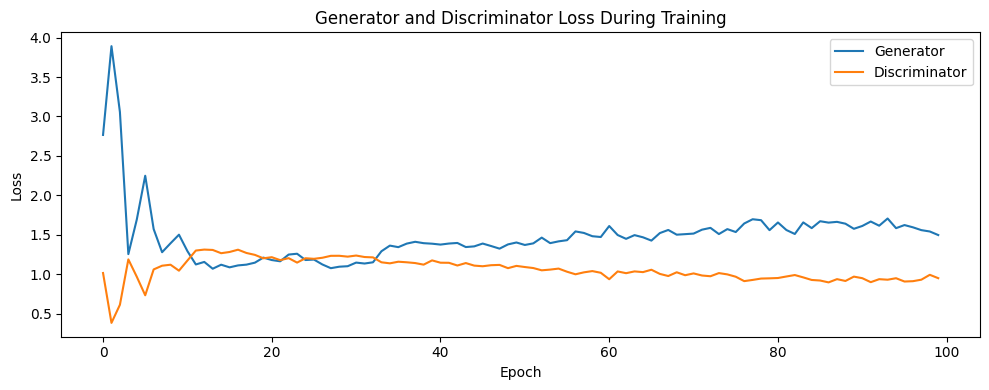

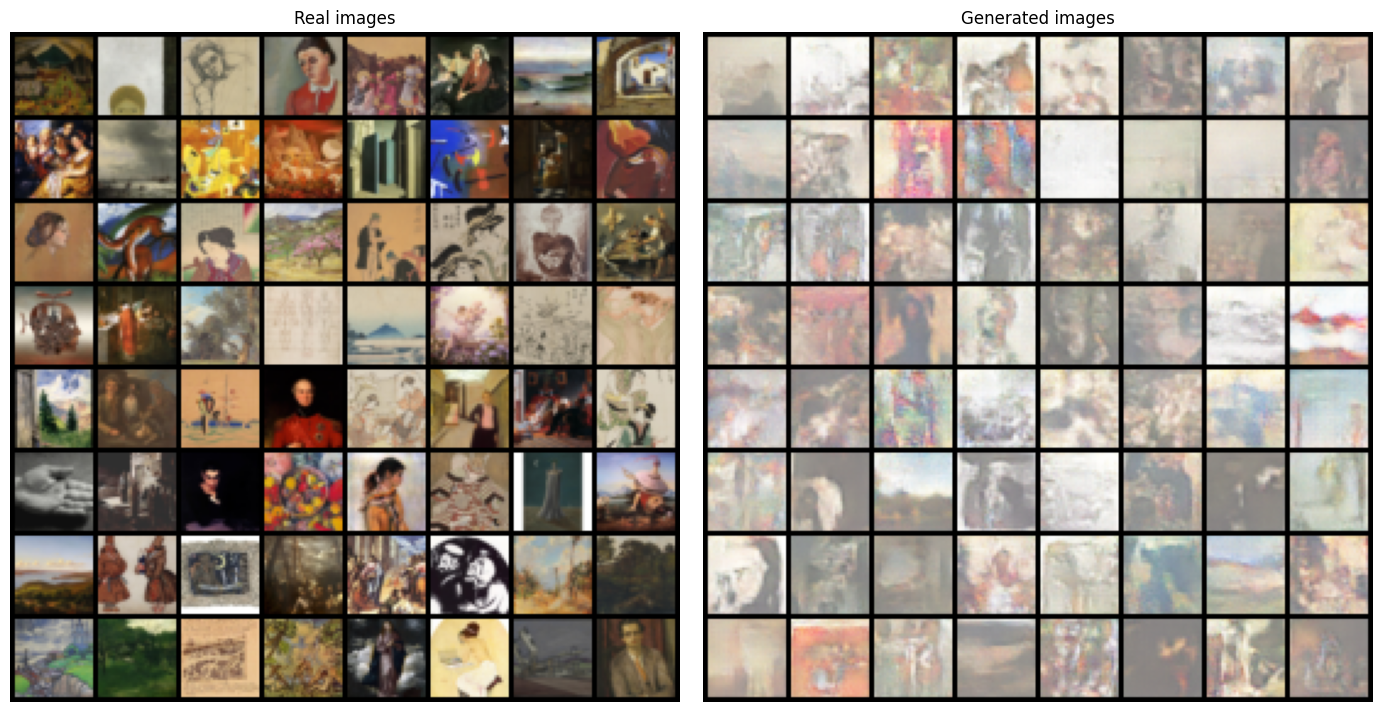

Artifacts saved in: artifacts/dcgan_v3_balanced_20260331_221231


ValueError: too many values to unpack (expected 3)

In [ ]:
gan_cfg = GANConfig(
    run_name = 'dcgan_v3_balanced',
    lr_d     = 1e-4,   # keep slower discriminator
    lr_g     = 1.5e-4, # pull back from 3e-4, still faster than D
    noise_dim = 256,
    ngf      = 128,
    ndf      = 64,
    epochs   = 100,
    use_csv_subset = True,
)

dcgan_report = run_dcgan_experiment(gan_cfg)

### V4

In [ ]:

# ── Discriminator ─────────────────────────────────────────────────────────────
class DCGANDiscriminator(nn.Module):
    def __init__(self, ndf: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf * 4, 1, 4, 1, 0, bias=False),
        )

    def forward(self, x):
        return self.net(x).view(-1, 1)



In [ ]:
#check device
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print("Using device:", device)

#v4 with BCEWithLogitsLoss and no sigmoid in discriminator
gan_cfg = GANConfig(
    run_name = 'dcgan_v4_logits',
    lr_d     = 1e-4,
    lr_g     = 1.5e-4,
    noise_dim = 256,
    ngf      = 128,
    ndf      = 64,
    epochs   = 100,
    use_csv_subset = True,
)

dcgan_report = run_dcgan_experiment(gan_cfg)

### V5

In [ ]:
#check device
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print("Using device:", device)

# v5 with more epochs
gan_cfg = GANConfig(
    run_name = 'dcgan_v4_logits',
    lr_d     = 1e-4,
    lr_g     = 1.5e-4,
    noise_dim = 256,
    ngf      = 128,
    ndf      = 64,
    epochs   = 200,
    use_csv_subset = True,
)

dcgan_report = run_dcgan_experiment(gan_cfg)

### V6

In [ ]:
from torch.nn.utils import spectral_norm

#v6 with spectral normalization in discriminator
class DCGANDiscriminator(nn.Module):
    def __init__(self, ndf: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            spectral_norm(nn.Conv2d(3, ndf, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),

            spectral_norm(nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False)),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),

            spectral_norm(nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False)),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),

            spectral_norm(nn.Conv2d(ndf * 4, 1, 4, 1, 0, bias=False)),
        )

    def forward(self, x):
        return self.net(x).view(-1, 1)

In [ ]:
gan_cfg = GANConfig(
    run_name='dcgan_v6_sn',
    lr_d=1e-4,
    lr_g=1.5e-4,
    noise_dim=256,
    ngf=128,
    ndf=64,
    epochs=100,
    use_csv_subset=True,
)
dcgan_report = run_dcgan_experiment(gan_cfg)



### V7

In [ ]:
from torch.nn.utils import spectral_norm

class DCGANDiscriminator(nn.Module):
    def __init__(self, ndf: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            spectral_norm(nn.Conv2d(3, ndf, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),

            spectral_norm(nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),

            spectral_norm(nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),

            spectral_norm(nn.Conv2d(ndf * 4, 1, 4, 1, 0, bias=False)),
        )

    def forward(self, x):
        return self.net(x).view(-1, 1)

In [ ]:
gan_cfg = GANConfig(
    run_name='dcgan_v7_sn_no_bn',
    lr_d=1e-4,
    lr_g=1.5e-4,
    noise_dim=256,
    ngf=128,
    ndf=64,
    epochs=100,
    use_csv_subset=True,
)
dcgan_report = run_dcgan_experiment(gan_cfg)

### 7b

In [ ]:
import torch.nn as nn
from torch.nn.utils import spectral_norm

# ── One epoch ─────────────────────────────────────────────────────────────────
def train_one_epoch_dcgan(generator, discriminator, loader, opt_g, opt_d,
                           device, noise_dim, max_steps=None):
    generator.train()
    discriminator.train()
    bce = nn.BCEWithLogitsLoss()
    sums = {'loss_g': 0.0, 'loss_d': 0.0, 'D_x': 0.0, 'D_G_z': 0.0}
    steps = 0

    for x_real, *_ in loader:
        x_real = x_real.to(device, non_blocking=True)
        bs = x_real.size(0)
        # y_real = torch.full((bs, 1), 1.0, device=device)
        y_real = torch.empty(bs, 1, device=device).uniform_(0.85, 1.0)
        y_fake = torch.zeros(bs, 1, device=device)

        # ── Discriminator ─────────────────────────────────────────────────────
        opt_d.zero_grad(set_to_none=True)
        out_real = discriminator(x_real)
        loss_real = bce(out_real, y_real)

        z = torch.randn(bs, noise_dim, 1, 1, device=device)
        x_fake = generator(z).detach()
        out_fake = discriminator(x_fake)
        loss_fake = bce(out_fake, y_fake)

        loss_d = loss_real + loss_fake
        loss_d.backward()
        opt_d.step()

        # ── Generator ─────────────────────────────────────────────────────────
        opt_g.zero_grad(set_to_none=True)
        z = torch.randn(bs, noise_dim, 1, 1, device=device)
        x_fake = generator(z)
        out_fake_for_g = discriminator(x_fake)
        loss_g = bce(out_fake_for_g, y_real)   # wants D to say "real"
        loss_g.backward()
        opt_g.step()

        sums['loss_d'] += float(loss_d.detach().cpu())
        sums['loss_g'] += float(loss_g.detach().cpu())
        sums['D_x']    += float(out_real.mean().detach().cpu())
        sums['D_G_z']  += float(out_fake_for_g.mean().detach().cpu())
        steps += 1

        if max_steps is not None and steps >= max_steps:
            break

    if steps == 0:
        raise RuntimeError('No training steps were executed.')
    return {k: v / steps for k, v in sums.items()}

class DCGANDiscriminator(nn.Module):
    def __init__(self, ndf: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            spectral_norm(nn.Conv2d(3, ndf, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),

            spectral_norm(nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False)),
            nn.InstanceNorm2d(ndf * 2, affine=True),
            nn.LeakyReLU(0.2, inplace=True),

            spectral_norm(nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False)),
            nn.InstanceNorm2d(ndf * 4, affine=True),
            nn.LeakyReLU(0.2, inplace=True),

            spectral_norm(nn.Conv2d(ndf * 4, 1, 4, 1, 0, bias=False)),
        )

    def forward(self, x):
        return self.net(x).view(-1, 1)

In [ ]:
gan_cfg = GANConfig(
    run_name='dcgan_v7b_in_sn',
    lr_d=1e-4,
    lr_g=1.5e-4,
    noise_dim=256,
    ngf=128,
    ndf=64,
    epochs=100,
    use_csv_subset=True,
)
dcgan_report = run_dcgan_experiment(gan_cfg)

### v8

In [ ]:
import torch.nn as nn
from torch.nn.utils import spectral_norm

# ── One epoch ─────────────────────────────────────────────────────────────────
def train_one_epoch_dcgan(generator, discriminator, loader, opt_g, opt_d,
                           device, noise_dim, max_steps=None):
    generator.train()
    discriminator.train()
    bce = nn.BCEWithLogitsLoss()
    sums = {'loss_g': 0.0, 'loss_d': 0.0, 'D_x': 0.0, 'D_G_z': 0.0}
    steps = 0

    for x_real, *_ in loader:
        x_real = x_real.to(device, non_blocking=True)
        bs = x_real.size(0)
        # y_real = torch.full((bs, 1), 1.0, device=device)
        y_real = torch.empty(bs, 1, device=device).uniform_(0.85, 1.0)
        y_fake = torch.zeros(bs, 1, device=device)

        # ── Discriminator ─────────────────────────────────────────────────────
        opt_d.zero_grad(set_to_none=True)
        out_real = discriminator(x_real)
        loss_real = bce(out_real, y_real)

        z = torch.randn(bs, noise_dim, 1, 1, device=device)
        x_fake = generator(z).detach()
        out_fake = discriminator(x_fake)
        loss_fake = bce(out_fake, y_fake)

        loss_d = loss_real + loss_fake
        loss_d.backward()
        opt_d.step()

        # ── Generator ─────────────────────────────────────────────────────────
        opt_g.zero_grad(set_to_none=True)
        z = torch.randn(bs, noise_dim, 1, 1, device=device)
        x_fake = generator(z)
        out_fake_for_g = discriminator(x_fake)
        loss_g = bce(out_fake_for_g, y_real)   # wants D to say "real"
        loss_g.backward()
        opt_g.step()

        sums['loss_d'] += float(loss_d.detach().cpu())
        sums['loss_g'] += float(loss_g.detach().cpu())
        sums['D_x']    += float(out_real.mean().detach().cpu())
        sums['D_G_z']  += float(out_fake_for_g.mean().detach().cpu())
        steps += 1

        if max_steps is not None and steps >= max_steps:
            break

    if steps == 0:
        raise RuntimeError('No training steps were executed.')
    return {k: v / steps for k, v in sums.items()}

class DCGANDiscriminator(nn.Module):
    def __init__(self, ndf: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            spectral_norm(nn.Conv2d(3, ndf, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),

            spectral_norm(nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False)),
            nn.InstanceNorm2d(ndf * 2, affine=True),
            nn.LeakyReLU(0.2, inplace=True),

            spectral_norm(nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False)),
            nn.InstanceNorm2d(ndf * 4, affine=True),
            nn.LeakyReLU(0.2, inplace=True),

            spectral_norm(nn.Conv2d(ndf * 4, 1, 4, 1, 0, bias=False)),
        )

    def forward(self, x):
        return self.net(x).view(-1, 1)

In [ ]:
gan_cfg = GANConfig(
    run_name='dcgan_v8_in_sn_32d',
    lr_d=1e-4,
    lr_g=1.5e-4,
    noise_dim=256,
    ngf=128,
    ndf=32,
    epochs=100,
    use_csv_subset=True,
)
dcgan_report = run_dcgan_experiment(gan_cfg)

### v9

In [ ]:
import torch.nn as nn
from torch.nn.utils import spectral_norm

# ── One epoch ─────────────────────────────────────────────────────────────────
def train_one_epoch_dcgan(generator, discriminator, loader, opt_g, opt_d,
                           device, noise_dim, max_steps=None):
    generator.train()
    discriminator.train()
    bce = nn.BCEWithLogitsLoss()
    sums = {'loss_g': 0.0, 'loss_d': 0.0, 'D_x': 0.0, 'D_G_z': 0.0}
    steps = 0

    for x_real, *_ in loader:
        x_real = x_real.to(device, non_blocking=True)
        bs = x_real.size(0)
        # y_real = torch.full((bs, 1), 1.0, device=device)
        y_real = torch.empty(bs, 1, device=device).uniform_(0.85, 1.0)
        y_fake = torch.zeros(bs, 1, device=device)

        # ── Discriminator ─────────────────────────────────────────────────────
        opt_d.zero_grad(set_to_none=True)
        out_real = discriminator(x_real)
        loss_real = bce(out_real, y_real)

        z = torch.randn(bs, noise_dim, 1, 1, device=device)
        x_fake = generator(z).detach()
        out_fake = discriminator(x_fake)
        loss_fake = bce(out_fake, y_fake)

        loss_d = loss_real + loss_fake
        loss_d.backward()
        opt_d.step()

        # ── Generator ─────────────────────────────────────────────────────────
        opt_g.zero_grad(set_to_none=True)
        z = torch.randn(bs, noise_dim, 1, 1, device=device)
        x_fake = generator(z)
        out_fake_for_g = discriminator(x_fake)
        loss_g = bce(out_fake_for_g, y_real)   # wants D to say "real"
        loss_g.backward()
        opt_g.step()

        sums['loss_d'] += float(loss_d.detach().cpu())
        sums['loss_g'] += float(loss_g.detach().cpu())
        sums['D_x']    += float(out_real.mean().detach().cpu())
        sums['D_G_z']  += float(out_fake_for_g.mean().detach().cpu())
        steps += 1

        if max_steps is not None and steps >= max_steps:
            break

    if steps == 0:
        raise RuntimeError('No training steps were executed.')
    return {k: v / steps for k, v in sums.items()}

class DCGANDiscriminator(nn.Module):
    def __init__(self, ndf: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            spectral_norm(nn.Conv2d(3, ndf, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),

            spectral_norm(nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False)),
            nn.InstanceNorm2d(ndf * 2, affine=True),
            nn.LeakyReLU(0.2, inplace=True),

            spectral_norm(nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False)),
            nn.InstanceNorm2d(ndf * 4, affine=True),
            nn.LeakyReLU(0.2, inplace=True),

            spectral_norm(nn.Conv2d(ndf * 4, 1, 4, 1, 0, bias=False)),
        )

    def forward(self, x):
        return self.net(x).view(-1, 1)

In [ ]:
gan_cfg = GANConfig(
    run_name='dcgan_v9_in_sn_lrd8e5',
    lr_d=8e-5,
    lr_g=1.5e-4,
    noise_dim=256,
    ngf=128,
    ndf=64,
    epochs=100,
    use_csv_subset=True,
)
dcgan_report = run_dcgan_experiment(gan_cfg)

### v10

In [ ]:
import torch.nn as nn
from torch.nn.utils import spectral_norm

# ── One epoch ─────────────────────────────────────────────────────────────────
def train_one_epoch_dcgan(generator, discriminator, loader, opt_g, opt_d,
                           device, noise_dim, max_steps=None):
    generator.train()
    discriminator.train()
    bce = nn.BCEWithLogitsLoss()
    sums = {'loss_g': 0.0, 'loss_d': 0.0, 'D_x': 0.0, 'D_G_z': 0.0}
    steps = 0

    for x_real, *_ in loader:
        x_real = x_real.to(device, non_blocking=True)
        bs = x_real.size(0)
        # y_real = torch.full((bs, 1), 1.0, device=device)
        y_real = torch.empty(bs, 1, device=device).uniform_(0.85, 1.0)
        y_fake = torch.zeros(bs, 1, device=device)

        # ── Discriminator ─────────────────────────────────────────────────────
        opt_d.zero_grad(set_to_none=True)
        out_real = discriminator(x_real)
        loss_real = bce(out_real, y_real)

        z = torch.randn(bs, noise_dim, 1, 1, device=device)
        x_fake = generator(z).detach()
        out_fake = discriminator(x_fake)
        loss_fake = bce(out_fake, y_fake)

        loss_d = loss_real + loss_fake
        loss_d.backward()
        opt_d.step()

        # ── Generator ─────────────────────────────────────────────────────────
        opt_g.zero_grad(set_to_none=True)
        z = torch.randn(bs, noise_dim, 1, 1, device=device)
        x_fake = generator(z)
        out_fake_for_g = discriminator(x_fake)
        loss_g = bce(out_fake_for_g, y_real)   # wants D to say "real"
        loss_g.backward()
        opt_g.step()

        sums['loss_d'] += float(loss_d.detach().cpu())
        sums['loss_g'] += float(loss_g.detach().cpu())
        sums['D_x']    += float(out_real.mean().detach().cpu())
        sums['D_G_z']  += float(out_fake_for_g.mean().detach().cpu())
        steps += 1

        if max_steps is not None and steps >= max_steps:
            break

    if steps == 0:
        raise RuntimeError('No training steps were executed.')
    return {k: v / steps for k, v in sums.items()}

class DCGANDiscriminator(nn.Module):
    def __init__(self, ndf: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            spectral_norm(nn.Conv2d(3, ndf, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),

            spectral_norm(nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False)),
            nn.InstanceNorm2d(ndf * 2, affine=True),
            nn.LeakyReLU(0.2, inplace=True),

            spectral_norm(nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False)),
            nn.InstanceNorm2d(ndf * 4, affine=True),
            nn.LeakyReLU(0.2, inplace=True),

            spectral_norm(nn.Conv2d(ndf * 4, 1, 4, 1, 0, bias=False)),
        )

    def forward(self, x):
        return self.net(x).view(-1, 1)

In [ ]:
gan_cfg = GANConfig(
    run_name='dcgan_v10_in_sn_lrd1e4_ndf48',
    lr_d=1e-4,
    lr_g=1.5e-4,
    noise_dim=256,
    ngf=128,
    ndf=48,
    epochs=100,
    use_csv_subset=True,
)
dcgan_report = run_dcgan_experiment(gan_cfg)

### v11

In [ ]:
import torch.nn as nn
from torch.nn.utils import spectral_norm

# ── One epoch ─────────────────────────────────────────────────────────────────
def train_one_epoch_dcgan(generator, discriminator, loader, opt_g, opt_d,
                           device, noise_dim, max_steps=None):
    generator.train()
    discriminator.train()
    bce = nn.BCEWithLogitsLoss()
    sums = {'loss_g': 0.0, 'loss_d': 0.0, 'D_x': 0.0, 'D_G_z': 0.0}
    steps = 0

    for x_real, *_ in loader:
        x_real = x_real.to(device, non_blocking=True)
        bs = x_real.size(0)
        # y_real = torch.full((bs, 1), 1.0, device=device)
        y_real = torch.empty(bs, 1, device=device).uniform_(0.85, 1.0)
        y_fake = torch.zeros(bs, 1, device=device)

        # ── Discriminator ─────────────────────────────────────────────────────
        opt_d.zero_grad(set_to_none=True)
        out_real = discriminator(x_real)
        loss_real = bce(out_real, y_real)

        z = torch.randn(bs, noise_dim, 1, 1, device=device)
        x_fake = generator(z).detach()
        out_fake = discriminator(x_fake)
        loss_fake = bce(out_fake, y_fake)

        loss_d = loss_real + loss_fake
        loss_d.backward()
        opt_d.step()

        # ── Generator ─────────────────────────────────────────────────────────
        opt_g.zero_grad(set_to_none=True)
        z = torch.randn(bs, noise_dim, 1, 1, device=device)
        x_fake = generator(z)
        out_fake_for_g = discriminator(x_fake)
        loss_g = bce(out_fake_for_g, y_real)   # wants D to say "real"
        loss_g.backward()
        opt_g.step()

        sums['loss_d'] += float(loss_d.detach().cpu())
        sums['loss_g'] += float(loss_g.detach().cpu())
        sums['D_x']    += float(out_real.mean().detach().cpu())
        sums['D_G_z']  += float(out_fake_for_g.mean().detach().cpu())
        steps += 1

        if max_steps is not None and steps >= max_steps:
            break

    if steps == 0:
        raise RuntimeError('No training steps were executed.')
    return {k: v / steps for k, v in sums.items()}

class DCGANDiscriminator(nn.Module):
    def __init__(self, ndf: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            spectral_norm(nn.Conv2d(3, ndf, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.25),

            spectral_norm(nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False)),
            nn.InstanceNorm2d(ndf * 2, affine=True),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.25),

            spectral_norm(nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False)),
            nn.InstanceNorm2d(ndf * 4, affine=True),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.25),

            spectral_norm(nn.Conv2d(ndf * 4, 1, 4, 1, 0, bias=False)),
        )

    def forward(self, x):
        return self.net(x).view(-1, 1)

In [ ]:
gan_cfg = GANConfig(
    run_name='dcgan_v11_in_sn_ndf64_dropout0.25',
    lr_d=8e-5,
    lr_g=1.5e-4,
    noise_dim=256,
    ngf=128,
    ndf=64,
    epochs=100,
    use_csv_subset=True,
)

dcgan_report = run_dcgan_experiment(gan_cfg)

### v12

In [ ]:
import torch.nn as nn
from torch.nn.utils import spectral_norm

# ── One epoch ─────────────────────────────────────────────────────────────────
def train_one_epoch_dcgan(generator, discriminator, loader, opt_g, opt_d,
                           device, noise_dim, max_steps=None):
    generator.train()
    discriminator.train()
    bce = nn.BCEWithLogitsLoss()
    sums = {'loss_g': 0.0, 'loss_d': 0.0, 'D_x': 0.0, 'D_G_z': 0.0}
    steps = 0

    for x_real, *_ in loader:
        x_real = x_real.to(device, non_blocking=True)
        bs = x_real.size(0)
        # y_real = torch.full((bs, 1), 1.0, device=device)
        y_real = torch.empty(bs, 1, device=device).uniform_(0.85, 1.0)
        y_fake = torch.zeros(bs, 1, device=device)

        # ── Discriminator ─────────────────────────────────────────────────────
        opt_d.zero_grad(set_to_none=True)
        out_real = discriminator(x_real)
        loss_real = bce(out_real, y_real)

        z = torch.randn(bs, noise_dim, 1, 1, device=device)
        x_fake = generator(z).detach()
        out_fake = discriminator(x_fake)
        loss_fake = bce(out_fake, y_fake)

        loss_d = loss_real + loss_fake
        loss_d.backward()
        opt_d.step()

        # ── Generator ─────────────────────────────────────────────────────────
        opt_g.zero_grad(set_to_none=True)
        z = torch.randn(bs, noise_dim, 1, 1, device=device)
        x_fake = generator(z)
        out_fake_for_g = discriminator(x_fake)
        loss_g = bce(out_fake_for_g, y_real)   # wants D to say "real"
        loss_g.backward()
        opt_g.step()

        sums['loss_d'] += float(loss_d.detach().cpu())
        sums['loss_g'] += float(loss_g.detach().cpu())
        sums['D_x']    += float(out_real.mean().detach().cpu())
        sums['D_G_z']  += float(out_fake_for_g.mean().detach().cpu())
        steps += 1

        if max_steps is not None and steps >= max_steps:
            break

    if steps == 0:
        raise RuntimeError('No training steps were executed.')
    return {k: v / steps for k, v in sums.items()}

class DCGANDiscriminator(nn.Module):
    def __init__(self, ndf: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            spectral_norm(nn.Conv2d(3, ndf, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.1),

            spectral_norm(nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False)),
            nn.InstanceNorm2d(ndf * 2, affine=True),    
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.1),

            spectral_norm(nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False)),
            nn.InstanceNorm2d(ndf * 4, affine=True),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.1),

            spectral_norm(nn.Conv2d(ndf * 4, 1, 4, 1, 0, bias=False)),
        )

    def forward(self, x):
        return self.net(x).view(-1, 1)

In [ ]:
gan_cfg = GANConfig(
    run_name='dcgan_v12_in_sn_dropout0p1',
    lr_d=8e-5,
    lr_g=1.5e-4,
    noise_dim=256,
    ngf=128,
    ndf=64,
    epochs=100,
    use_csv_subset=True,
)

dcgan_report = run_dcgan_experiment(gan_cfg)

### v13

In [ ]:
import torch.nn as nn
from torch.nn.utils import spectral_norm


# ── One epoch ─────────────────────────────────────────────────────────────────
def train_one_epoch_dcgan(generator, discriminator, loader, opt_g, opt_d,
                           device, noise_dim, max_steps=None):
    generator.train()
    discriminator.train()
    bce = nn.BCELoss()
    sums = {'loss_g': 0.0, 'loss_d': 0.0, 'D_x': 0.0, 'D_G_z': 0.0}
    steps = 0

    for x_real, *_ in loader:
        x_real = x_real.to(device, non_blocking=True)
        bs = x_real.size(0)

        y_real = torch.empty(bs, 1, device=device).uniform_(0.85, 1.0)
        y_fake = torch.zeros(bs, 1, device=device)

        # ── Discriminator ─────────────────────────────────────────────────────
        opt_d.zero_grad(set_to_none=True)
        out_real = discriminator(x_real)
        loss_real = bce(out_real, y_real)

        z = torch.randn(bs, noise_dim, 1, 1, device=device)
        x_fake = generator(z).detach()
        out_fake = discriminator(x_fake)
        loss_fake = bce(out_fake, y_fake)

        loss_d = loss_real + loss_fake
        loss_d.backward()
        opt_d.step()

        # ── Generator ─────────────────────────────────────────────────────────
        opt_g.zero_grad(set_to_none=True)
        z = torch.randn(bs, noise_dim, 1, 1, device=device)
        x_fake = generator(z)
        out_fake_for_g = discriminator(x_fake)
        loss_g = bce(out_fake_for_g, y_real)
        loss_g.backward()
        opt_g.step()

        sums['loss_d'] += float(loss_d.detach().cpu())
        sums['loss_g'] += float(loss_g.detach().cpu())
        sums['D_x']    += float(out_real.mean().detach().cpu())
        sums['D_G_z']  += float(out_fake_for_g.mean().detach().cpu())
        steps += 1

        if max_steps is not None and steps >= max_steps:
            break

    if steps == 0:
        raise RuntimeError('No training steps were executed.')
    return {k: v / steps for k, v in sums.items()}


class DCGANDiscriminator(nn.Module):
    def __init__(self, ndf: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            spectral_norm(nn.Conv2d(3, ndf, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.3),

            spectral_norm(nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False)),
            nn.InstanceNorm2d(ndf * 2, affine=True),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.3),

            spectral_norm(nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False)),
            nn.InstanceNorm2d(ndf * 4, affine=True),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.3),

            spectral_norm(nn.Conv2d(ndf * 4, 1, 4, 1, 0, bias=False)),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.net(x).view(-1, 1)

In [ ]:
gan_cfg = GANConfig(
    run_name='dcgan_v13_bce_dropout0p3',
    lr_d=8e-5,
    lr_g=1.5e-4,
    noise_dim=256,
    ngf=128,
    ndf=64,
    epochs=100,
    use_csv_subset=True,
)

dcgan_report = run_dcgan_experiment(gan_cfg)

### v14

In [ ]:
import torch.nn as nn
from torch.nn.utils import spectral_norm


# ── One epoch ─────────────────────────────────────────────────────────────────
def train_one_epoch_dcgan(generator, discriminator, loader, opt_g, opt_d,
                           device, noise_dim, max_steps=None):
    generator.train()
    discriminator.train()
    bce = nn.BCELoss()
    sums = {'loss_g': 0.0, 'loss_d': 0.0, 'D_x': 0.0, 'D_G_z': 0.0}
    steps = 0

    for x_real, *_ in loader:
        x_real = x_real.to(device, non_blocking=True)
        bs = x_real.size(0)

        y_real = torch.empty(bs, 1, device=device).uniform_(0.85, 1.0)
        y_fake = torch.zeros(bs, 1, device=device)

        # ── Discriminator ─────────────────────────────────────────────────────
        opt_d.zero_grad(set_to_none=True)
        out_real = discriminator(x_real)
        loss_real = bce(out_real, y_real)

        z = torch.randn(bs, noise_dim, 1, 1, device=device)
        x_fake = generator(z).detach()
        out_fake = discriminator(x_fake)
        loss_fake = bce(out_fake, y_fake)

        loss_d = loss_real + loss_fake
        loss_d.backward()
        opt_d.step()

        # ── Generator ─────────────────────────────────────────────────────────
        opt_g.zero_grad(set_to_none=True)
        z = torch.randn(bs, noise_dim, 1, 1, device=device)
        x_fake = generator(z)
        out_fake_for_g = discriminator(x_fake)
        loss_g = bce(out_fake_for_g, y_real)
        loss_g.backward()
        opt_g.step()

        sums['loss_d'] += float(loss_d.detach().cpu())
        sums['loss_g'] += float(loss_g.detach().cpu())
        sums['D_x']    += float(out_real.mean().detach().cpu())
        sums['D_G_z']  += float(out_fake_for_g.mean().detach().cpu())
        steps += 1

        if max_steps is not None and steps >= max_steps:
            break

    if steps == 0:
        raise RuntimeError('No training steps were executed.')
    return {k: v / steps for k, v in sums.items()}


class DCGANDiscriminator(nn.Module):
    def __init__(self, ndf: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            spectral_norm(nn.Conv2d(3, ndf, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.4),

            spectral_norm(nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False)),
            nn.InstanceNorm2d(ndf * 2, affine=True),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.4),

            spectral_norm(nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False)),
            nn.InstanceNorm2d(ndf * 4, affine=True),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.4),

            spectral_norm(nn.Conv2d(ndf * 4, 1, 4, 1, 0, bias=False)),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.net(x).view(-1, 1)

In [ ]:
gan_cfg = GANConfig(
    run_name='dcgan_v14_bce_dropout0p4',
    lr_d=1e-4,
    lr_g=1.5e-4,
    noise_dim=256,
    ngf=128,
    ndf=64,
    epochs=100,
    use_csv_subset=True,
)

dcgan_report = run_dcgan_experiment(gan_cfg)

## Diffusion (Modular DDPM)

test 1 artifacts/ddpm_baseline_dev_20260421_104139

DDPM params: 62,438,883


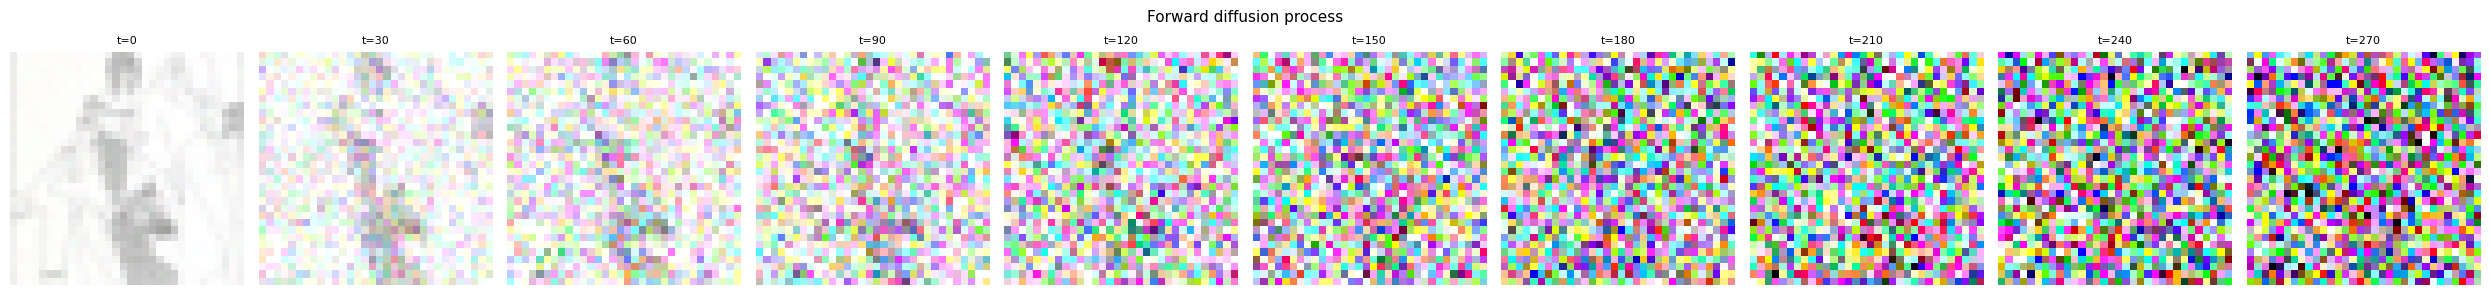

[DDPM][Epoch 001/100] loss=0.2599
[DDPM][Epoch 002/100] loss=0.1529
[DDPM][Epoch 003/100] loss=0.1556
[DDPM][Epoch 004/100] loss=0.1429
[DDPM][Epoch 005/100] loss=0.1379
[DDPM][Epoch 006/100] loss=0.1338
[DDPM][Epoch 007/100] loss=0.1337
[DDPM][Epoch 008/100] loss=0.1325
[DDPM][Epoch 009/100] loss=0.1305
[DDPM][Epoch 010/100] loss=0.1310
[DDPM][Epoch 011/100] loss=0.1318
[DDPM][Epoch 012/100] loss=0.1260
[DDPM][Epoch 013/100] loss=0.1282
[DDPM][Epoch 014/100] loss=0.1273
[DDPM][Epoch 015/100] loss=0.1255
[DDPM][Epoch 016/100] loss=0.1252
[DDPM][Epoch 017/100] loss=0.1252
[DDPM][Epoch 018/100] loss=0.1246
[DDPM][Epoch 019/100] loss=0.1243
[DDPM][Epoch 020/100] loss=0.1248
[DDPM][Epoch 021/100] loss=0.1246
[DDPM][Epoch 022/100] loss=0.1241
[DDPM][Epoch 023/100] loss=0.1233
[DDPM][Epoch 024/100] loss=0.1235
[DDPM][Epoch 025/100] loss=0.1221
[DDPM][Epoch 026/100] loss=0.1226
[DDPM][Epoch 027/100] loss=0.1230
[DDPM][Epoch 028/100] loss=0.1211
[DDPM][Epoch 029/100] loss=0.1223
[DDPM][Epoch 0

In [15]:
# ── Config ────────────────────────────────────────────────────────────────────
@dataclass
class DDPMConfig:
    run_name: str = 'ddpm_baseline_dev'
    seed: int = 42
    epochs: int = 100
    lr: float = 1e-3
    T: int = 300                          # diffusion timesteps
    beta_start: float = 0.0001
    beta_end: float = 0.02
    use_csv_subset: bool = True
    max_train_steps_per_epoch: int | None = None


# ── Beta schedule & precomputed terms ─────────────────────────────────────────
def build_diffusion_constants(T: int, beta_start: float, beta_end: float, device: torch.device) -> dict:
    betas = torch.linspace(beta_start, beta_end, T)
    alphas = 1.0 - betas
    alphas_cumprod = torch.cumprod(alphas, dim=0)
    alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)
    return {
        'betas':                          betas.to(device),
        'sqrt_recip_alphas':              torch.sqrt(1.0 / alphas).to(device),
        'sqrt_alphas_cumprod':            torch.sqrt(alphas_cumprod).to(device),
        'sqrt_one_minus_alphas_cumprod':  torch.sqrt(1.0 - alphas_cumprod).to(device),
        'posterior_variance':             (betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)).to(device),
    }


def get_index_from_list(vals: torch.Tensor, t: torch.Tensor, x_shape) -> torch.Tensor:
    out = vals.gather(-1, t.to(vals.device))
    return out.reshape(t.shape[0], *((1,) * (len(x_shape) - 1))).to(t.device)


def forward_diffusion_sample(x_0: torch.Tensor, t: torch.Tensor, dc: dict) -> tuple:
    noise = torch.randn_like(x_0)
    sqrt_ac_t  = get_index_from_list(dc['sqrt_alphas_cumprod'], t, x_0.shape)
    sqrt_omc_t = get_index_from_list(dc['sqrt_one_minus_alphas_cumprod'], t, x_0.shape)
    return sqrt_ac_t * x_0 + sqrt_omc_t * noise, noise


# ── U-Net ─────────────────────────────────────────────────────────────────────
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim: int):
        super().__init__()
        self.dim = dim

    def forward(self, time: torch.Tensor) -> torch.Tensor:
        device = time.device
        half_dim = self.dim // 2
        emb = math.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=device) * -emb)
        emb = time[:, None] * emb[None, :]
        return torch.cat((emb.sin(), emb.cos()), dim=-1)


class Block(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, time_emb_dim: int, up: bool = False):
        super().__init__()
        self.time_mlp = nn.Linear(time_emb_dim, out_ch)
        if up:
            self.conv1     = nn.Conv2d(2 * in_ch, out_ch, 3, padding=1)
            self.transform = nn.ConvTranspose2d(out_ch, out_ch, 4, 2, 1)
        else:
            self.conv1     = nn.Conv2d(in_ch, out_ch, 3, padding=1)
            self.transform = nn.Conv2d(out_ch, out_ch, 4, 2, 1)
        self.conv2  = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.bnorm1 = nn.BatchNorm2d(out_ch)
        self.bnorm2 = nn.BatchNorm2d(out_ch)
        self.relu   = nn.ReLU()

    def forward(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        h = self.bnorm1(self.relu(self.conv1(x)))
        t_emb = self.relu(self.time_mlp(t))[(...,) + (None,) * 2]
        h = self.bnorm2(self.relu(self.conv2(h + t_emb)))
        return self.transform(h)


class SimpleUnet(nn.Module):
    def __init__(self, image_channels: int = 3, time_emb_dim: int = 32):
        super().__init__()
        down_channels = (64, 128, 256, 512, 1024)
        up_channels   = (1024, 512, 256, 128, 64)

        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.ReLU(),
        )
        self.conv0 = nn.Conv2d(image_channels, down_channels[0], 3, padding=1)
        self.downs = nn.ModuleList([
            Block(down_channels[i], down_channels[i + 1], time_emb_dim)
            for i in range(len(down_channels) - 1)
        ])
        self.ups = nn.ModuleList([
            Block(up_channels[i], up_channels[i + 1], time_emb_dim, up=True)
            for i in range(len(up_channels) - 1)
        ])
        self.output = nn.Conv2d(up_channels[-1], image_channels, 1)

    def forward(self, x: torch.Tensor, timestep: torch.Tensor) -> torch.Tensor:
        t = self.time_mlp(timestep)
        x = self.conv0(x)
        residuals = []
        for down in self.downs:
            x = down(x, t)
            residuals.append(x)
        for up in self.ups:
            x = torch.cat((x, residuals.pop()), dim=1)
            x = up(x, t)
        return self.output(x)


# ── Loss ──────────────────────────────────────────────────────────────────────
def ddpm_loss(model: SimpleUnet, x_0: torch.Tensor, t: torch.Tensor, dc: dict) -> torch.Tensor:
    x_noisy, noise = forward_diffusion_sample(x_0, t, dc)
    noise_pred = model(x_noisy, t)
    return F.l1_loss(noise, noise_pred)


# ── One epoch ─────────────────────────────────────────────────────────────────
def train_one_epoch_ddpm(model, loader, optimizer, device, dc, T, max_steps=None):
    model.train()
    total_loss, steps = 0.0, 0

    for x, *_ in loader:
        x = x.to(device, non_blocking=True)
        t = torch.randint(0, T, (x.size(0),), device=device).long()
        optimizer.zero_grad(set_to_none=True)
        loss = ddpm_loss(model, x, t, dc)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        steps += 1
        if max_steps is not None and steps >= max_steps:
            break

    if steps == 0:
        raise RuntimeError('No training steps executed.')
    return total_loss / steps


# ── Sampling ──────────────────────────────────────────────────────────────────
@torch.no_grad()
def sample_ddpm(model: SimpleUnet, n_samples: int, image_size: int,
                device: torch.device, dc: dict, T: int) -> torch.Tensor:
    model.eval()
    img = torch.randn((n_samples, 3, image_size, image_size), device=device)

    for i in reversed(range(T)):
        t = torch.full((n_samples,), i, device=device, dtype=torch.long)
        betas_t    = get_index_from_list(dc['betas'], t, img.shape)
        sqrt_omc_t = get_index_from_list(dc['sqrt_one_minus_alphas_cumprod'], t, img.shape)
        sqrt_ra_t  = get_index_from_list(dc['sqrt_recip_alphas'], t, img.shape)
        post_var_t = get_index_from_list(dc['posterior_variance'], t, img.shape)

        model_mean = sqrt_ra_t * (img - betas_t * model(img, t) / sqrt_omc_t)
        if i > 0:
            img = model_mean + torch.sqrt(post_var_t) * torch.randn_like(img)
        else:
            img = model_mean

        img = img.clamp(-1.0, 1.0)

    # Denorm [-1,1] → [0,1]
    return (img + 1) / 2


# ── Visualize diffusion noising progression ───────────────────────────────────
def show_diffusion_steps(loader, dc: dict, T: int, n_steps: int = 10):
    x = next(iter(loader))[0]
    stepsize = T // n_steps
    fig, axes = plt.subplots(1, n_steps, figsize=(2.5 * n_steps, 3))
    for idx, ax in enumerate(axes):
        t = torch.tensor([idx * stepsize], dtype=torch.long)
        noisy, _ = forward_diffusion_sample(x[:1], t, dc)
        img = (noisy[0].clamp(-1, 1) + 1) / 2
        ax.imshow(img.permute(1, 2, 0).cpu().numpy())
        ax.set_title(f't={idx * stepsize}', fontsize=8)
        ax.axis('off')
    plt.suptitle('Forward diffusion process', fontsize=11)
    plt.tight_layout()
    plt.show()


# ── Experiment ────────────────────────────────────────────────────────────────
def run_ddpm_experiment(cfg: DDPMConfig) -> dict:
    set_global_seed(cfg.seed)
    device  = get_device()
    loader  = get_active_train_loader(cfg.use_csv_subset)
    run_dir = make_run_dir(ARTIFACTS_ROOT, cfg.run_name)

    dc    = build_diffusion_constants(cfg.T, cfg.beta_start, cfg.beta_end, device)
    model = SimpleUnet().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr)

    print(f'DDPM params: {sum(p.numel() for p in model.parameters()):,}')
    show_diffusion_steps(loader, dc, cfg.T)   # visualize noising before training

    history = []
    for epoch in range(1, cfg.epochs + 1):
        avg_loss = train_one_epoch_ddpm(
            model, loader, optimizer, device, dc, cfg.T,
            max_steps=cfg.max_train_steps_per_epoch,
        )
        history.append({'epoch': epoch, 'loss': avg_loss})
        print(f'[DDPM][Epoch {epoch:03d}/{cfg.epochs}] loss={avg_loss:.4f}')

    # ── Save checkpoint ───────────────────────────────────────────────────────
    ckpt_path = run_dir / 'ddpm.pt'
    torch.save(model.state_dict(), ckpt_path)

    # ── Generate & save sample grid ───────────────────────────────────────────
    samples = sample_ddpm(model, n_samples=64, image_size=IMAGE_SIZE,
                          device=device, dc=dc, T=cfg.T)
    preview_path = run_dir / 'samples_grid.png'
    save_image(make_grid(samples, nrow=8, padding=2), preview_path)

    report = {
        'config':        asdict(cfg),
        'history':       history,
        'checkpoint_path': str(ckpt_path),
        'preview_grid_path': str(preview_path),
    }
    save_json(run_dir / 'train_report.json', report)
    print('Artifacts saved in:', run_dir)
    return report, model


# ── Run ───────────────────────────────────────────────────────────────────────
ddpm_cfg = DDPMConfig()
ddpm_report, ddpm_model = run_ddpm_experiment(ddpm_cfg)

test 2 artifacts/ddpm_v2_20260421_123441

DDPM params: 3,692,003


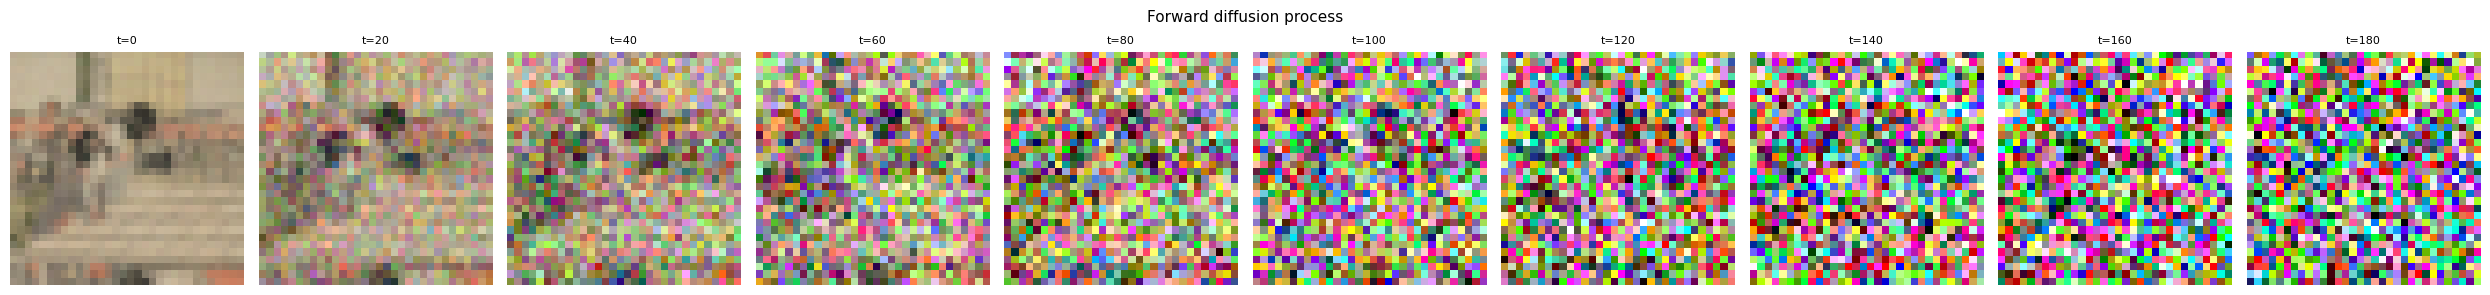

[DDPM][Epoch 001/100] loss=0.3546
[DDPM][Epoch 002/100] loss=0.2532
[DDPM][Epoch 003/100] loss=0.2190
[DDPM][Epoch 004/100] loss=0.2151
[DDPM][Epoch 005/100] loss=0.2081
[DDPM][Epoch 006/100] loss=0.2069
[DDPM][Epoch 007/100] loss=0.2029
[DDPM][Epoch 008/100] loss=0.2034
[DDPM][Epoch 009/100] loss=0.2011
[DDPM][Epoch 010/100] loss=0.2019
[DDPM][Epoch 011/100] loss=0.2015
[DDPM][Epoch 012/100] loss=0.1973
[DDPM][Epoch 013/100] loss=0.1982
[DDPM][Epoch 014/100] loss=0.1964
[DDPM][Epoch 015/100] loss=0.1972
[DDPM][Epoch 016/100] loss=0.1953
[DDPM][Epoch 017/100] loss=0.1973
[DDPM][Epoch 018/100] loss=0.1973
[DDPM][Epoch 019/100] loss=0.1958
[DDPM][Epoch 020/100] loss=0.1950
[DDPM][Epoch 021/100] loss=0.1955
[DDPM][Epoch 022/100] loss=0.1942
[DDPM][Epoch 023/100] loss=0.1938
[DDPM][Epoch 024/100] loss=0.1935
[DDPM][Epoch 025/100] loss=0.1922
[DDPM][Epoch 026/100] loss=0.1903
[DDPM][Epoch 027/100] loss=0.1900
[DDPM][Epoch 028/100] loss=0.1910
[DDPM][Epoch 029/100] loss=0.1898
[DDPM][Epoch 0

In [16]:
"""
train_loader_from_csv uses [0,1] normalization but DDPM expects [-1,1].
Dedicated DDPM loader:
"""
def get_ddpm_loader(use_csv_subset: bool, image_size: int, batch_size: int) -> DataLoader:
    from torchvision import transforms as T
    ddpm_transform = T.Compose([
        T.Resize((image_size, image_size)),
        T.ToTensor(),
        T.Lambda(lambda t: (t * 2) - 1),   # [0,1] → [-1,1]  ← this is what was missing
    ])
    dataset = HFDatasetTorch(train_hf, transform=ddpm_transform,
                             indices=train_ids_from_csv if use_csv_subset else None)
    return DataLoader(dataset, batch_size=batch_size, shuffle=True,
                      num_workers=EFFECTIVE_NUM_WORKERS, pin_memory=torch.cuda.is_available())

"""
IMAGE_SIZE=32, the 5-level UNet downsamples 32→16→8→4→2→1
Bottleneck collapses to 1×1.
Shrink it to 3 levels:
"""
class SimpleUnet2(nn.Module):
    def __init__(self, image_channels: int = 3, time_emb_dim: int = 32):
        super().__init__()
        down_channels = (64, 128, 256)      # was (64,128,256,512,1024)
        up_channels   = (256, 128, 64)      # was (1024,512,256,128,64)

        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.ReLU(),
        )
        self.conv0 = nn.Conv2d(image_channels, down_channels[0], 3, padding=1)
        self.downs = nn.ModuleList([
            Block(down_channels[i], down_channels[i + 1], time_emb_dim)
            for i in range(len(down_channels) - 1)
        ])
        self.ups = nn.ModuleList([
            Block(up_channels[i], up_channels[i + 1], time_emb_dim, up=True)
            for i in range(len(up_channels) - 1)
        ])
        self.output = nn.Conv2d(up_channels[-1], image_channels, 1)

    def forward(self, x: torch.Tensor, timestep: torch.Tensor) -> torch.Tensor:
        t = self.time_mlp(timestep)
        x = self.conv0(x)
        residuals = []
        for down in self.downs:
            x = down(x, t)
            residuals.append(x)
        for up in self.ups:
            x = torch.cat((x, residuals.pop()), dim=1)
            x = up(x, t)
        return self.output(x)

"""
1h30 for 100 epochs is mostly the UNet size.
The 3-level version above will be ~10x faster.
Also reduce T:
"""
ddpm_cfg = DDPMConfig(
    run_name = 'ddpm_v2',
    T        = 200,    # was 300, less steps = faster sampling
    epochs   = 100,
    lr       = 1e-3,
    use_csv_subset = True,
)

# ── Experiment ────────────────────────────────────────────────────────────────
def run_ddpm_experiment(cfg: DDPMConfig) -> dict:
    set_global_seed(cfg.seed)
    device  = get_device()
    loader = get_ddpm_loader(cfg.use_csv_subset, IMAGE_SIZE, BATCH_SIZE) # different
    run_dir = make_run_dir(ARTIFACTS_ROOT, cfg.run_name)

    dc    = build_diffusion_constants(cfg.T, cfg.beta_start, cfg.beta_end, device)
    model = SimpleUnet2().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr)

    print(f'DDPM params: {sum(p.numel() for p in model.parameters()):,}')
    show_diffusion_steps(loader, dc, cfg.T)   # visualize noising before training

    history = []
    for epoch in range(1, cfg.epochs + 1):
        avg_loss = train_one_epoch_ddpm(
            model, loader, optimizer, device, dc, cfg.T,
            max_steps=cfg.max_train_steps_per_epoch,
        )
        history.append({'epoch': epoch, 'loss': avg_loss})
        print(f'[DDPM][Epoch {epoch:03d}/{cfg.epochs}] loss={avg_loss:.4f}')

    # ── Save checkpoint ───────────────────────────────────────────────────────
    ckpt_path = run_dir / 'ddpm.pt'
    torch.save(model.state_dict(), ckpt_path)

    # ── Generate & save sample grid ───────────────────────────────────────────
    samples = sample_ddpm(model, n_samples=64, image_size=IMAGE_SIZE,
                          device=device, dc=dc, T=cfg.T)
    preview_path = run_dir / 'samples_grid.png'
    save_image(make_grid(samples, nrow=8, padding=2), preview_path)

    report = {
        'config':        asdict(cfg),
        'history':       history,
        'checkpoint_path': str(ckpt_path),
        'preview_grid_path': str(preview_path),
    }
    save_json(run_dir / 'train_report.json', report)
    print('Artifacts saved in:', run_dir)
    return report, model


# ── Run ───────────────────────────────────────────────────────────────────────
# ddpm_cfg = DDPMConfig()
ddpm_report, ddpm_model = run_ddpm_experiment(ddpm_cfg)

test 3

DDPM params: 3,692,003


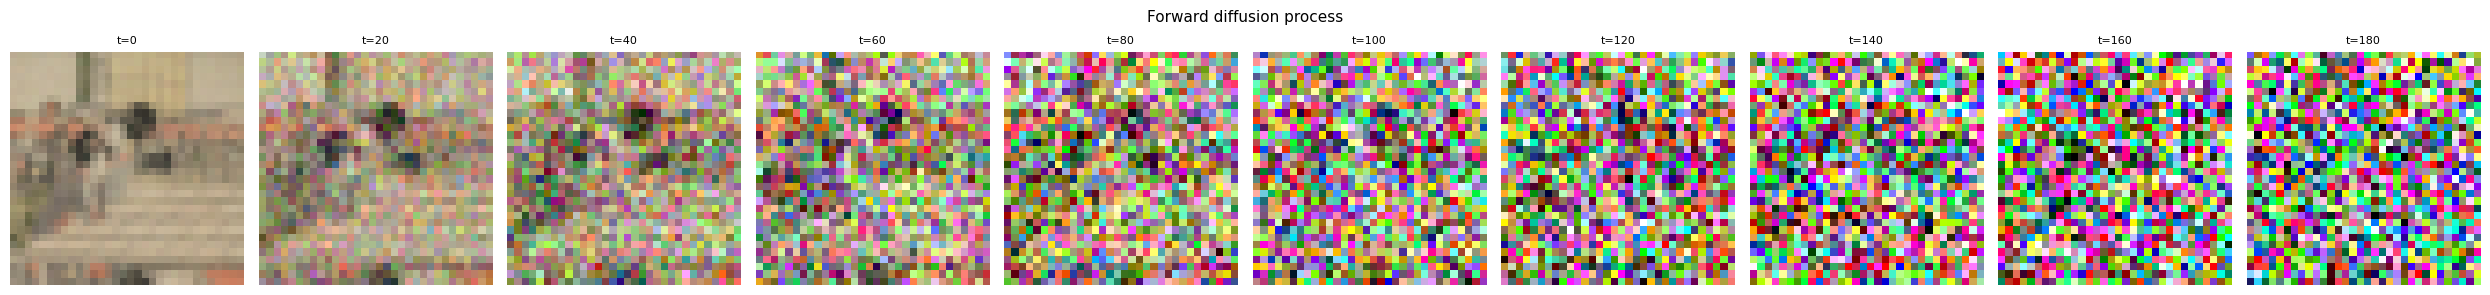

[DDPM][Epoch 001/100] loss=0.2175
[DDPM][Epoch 002/100] loss=0.1055
[DDPM][Epoch 003/100] loss=0.0947
[DDPM][Epoch 004/100] loss=0.0938
[DDPM][Epoch 005/100] loss=0.0890
[DDPM][Epoch 006/100] loss=0.0902
[DDPM][Epoch 007/100] loss=0.0862
[DDPM][Epoch 008/100] loss=0.0873
[DDPM][Epoch 009/100] loss=0.0856
[DDPM][Epoch 010/100] loss=0.0869
[DDPM][Epoch 011/100] loss=0.0855
[DDPM][Epoch 012/100] loss=0.0822
[DDPM][Epoch 013/100] loss=0.0833
[DDPM][Epoch 014/100] loss=0.0826
[DDPM][Epoch 015/100] loss=0.0827
[DDPM][Epoch 016/100] loss=0.0820
[DDPM][Epoch 017/100] loss=0.0827
[DDPM][Epoch 018/100] loss=0.0835
[DDPM][Epoch 019/100] loss=0.0817
[DDPM][Epoch 020/100] loss=0.0819
[DDPM][Epoch 021/100] loss=0.0822
[DDPM][Epoch 022/100] loss=0.0806
[DDPM][Epoch 023/100] loss=0.0808
[DDPM][Epoch 024/100] loss=0.0802
[DDPM][Epoch 025/100] loss=0.0796
[DDPM][Epoch 026/100] loss=0.0781
[DDPM][Epoch 027/100] loss=0.0778
[DDPM][Epoch 028/100] loss=0.0793
[DDPM][Epoch 029/100] loss=0.0778
[DDPM][Epoch 0

In [30]:
class Block(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim, up=False):
        super().__init__()
        self.time_mlp = nn.Linear(time_emb_dim, out_ch)

        if up:
            self.conv1 = nn.Conv2d(2 * in_ch, out_ch, 3, padding=1)
            self.transform = nn.ConvTranspose2d(out_ch, out_ch, 4, 2, 1)
        else:
            self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
            self.transform = nn.Conv2d(out_ch, out_ch, 4, 2, 1)

        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)

        self.norm1 = nn.GroupNorm(8, out_ch)
        self.norm2 = nn.GroupNorm(8, out_ch)

        self.act = nn.SiLU()   # better than ReLU for diffusion

    def forward(self, x, t):
        h = self.norm1(self.act(self.conv1(x)))

        t_emb = self.act(self.time_mlp(t))[:, :, None, None]
        h = h + t_emb

        h = self.norm2(self.act(self.conv2(h)))

        return self.transform(h)

def ddpm_loss(model, x_0, t, dc):
    x_noisy, noise = forward_diffusion_sample(x_0, t, dc)
    noise_pred = model(x_noisy, t)
    return F.mse_loss(noise_pred, noise) #MSE instead of L1

model = SimpleUnet2().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

def train_one_epoch_ddpm(model, loader, optimizer, device, dc, T):
    model.train()
    total_loss = 0

    for x, *_ in loader:
        x = x.to(device)

        t = torch.randint(0, T, (x.size(0),), device=device)

        loss = ddpm_loss(model, x, t, dc)

        optimizer.zero_grad()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) # small stabilization trick

        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

# ── Experiment ────────────────────────────────────────────────────────────────
def run_ddpm_experiment(cfg: DDPMConfig) -> dict:
    set_global_seed(cfg.seed)
    device  = get_device()
    loader = get_ddpm_loader(cfg.use_csv_subset, IMAGE_SIZE, BATCH_SIZE) # different
    run_dir = make_run_dir(ARTIFACTS_ROOT, cfg.run_name)

    dc    = build_diffusion_constants(cfg.T, cfg.beta_start, cfg.beta_end, device)
    model = SimpleUnet2().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr)

    print(f'DDPM params: {sum(p.numel() for p in model.parameters()):,}')
    show_diffusion_steps(loader, dc, cfg.T)   # visualize noising before training

    history = []
    for epoch in range(1, cfg.epochs + 1):
        avg_loss = train_one_epoch_ddpm(
            model, loader, optimizer, device, dc, cfg.T
        )
        history.append({'epoch': epoch, 'loss': avg_loss})
        print(f'[DDPM][Epoch {epoch:03d}/{cfg.epochs}] loss={avg_loss:.4f}')

    # ── Save checkpoint ───────────────────────────────────────────────────────
    ckpt_path = run_dir / 'ddpm.pt'
    torch.save(model.state_dict(), ckpt_path)

    # ── Generate & save sample grid ───────────────────────────────────────────
    samples = sample_ddpm(model, n_samples=64, image_size=IMAGE_SIZE,
                          device=device, dc=dc, T=cfg.T)
    preview_path = run_dir / 'samples_grid.png'
    save_image(make_grid(samples, nrow=8, padding=2), preview_path)

    report = {
        'config':        asdict(cfg),
        'history':       history,
        'checkpoint_path': str(ckpt_path),
        'preview_grid_path': str(preview_path),
    }
    save_json(run_dir / 'train_report.json', report)
    print('Artifacts saved in:', run_dir)
    return report, model


# ── Run ───────────────────────────────────────────────────────────────────────
# ddpm_cfg = DDPMConfig()
ddpm_report, ddpm_model = run_ddpm_experiment(ddpm_cfg)

## Evaluation (Shared FID/KID Pipeline)

In [ ]:
from statistics import mean, pstdev
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.kid import KernelInceptionDistance


@dataclass
class EvalConfig:
    n_generated: int = 5000
    n_real: int = 5000
    kid_subsets: int = 50
    kid_subset_size: int = 100
    metric_batch_size: int = 256


def tensor_to_uint8(x: torch.Tensor) -> torch.Tensor:
    x = x.detach().cpu().clamp(0.0, 1.0)
    return (x * 255.0).round().to(torch.uint8)


def sample_real_images_from_hf(
    hf_split,
    transform,
    n_samples: int,
    seed: int,
 ) -> torch.Tensor:
    rng = np.random.RandomState(seed)
    indices = np.arange(len(hf_split))
    rng.shuffle(indices)
    selected = indices[:n_samples].tolist()
    real = []
    for idx in selected:
        x = transform(hf_split[idx]['image'])
        real.append(x)
    return torch.stack(real, dim=0)


def compute_fid_kid(
    generated: torch.Tensor,
    real: torch.Tensor,
    device: torch.device,
    cfg_eval: EvalConfig,
) -> dict:
    gen_u8 = tensor_to_uint8(generated)
    real_u8 = tensor_to_uint8(real)

    fid = FrechetInceptionDistance(feature=2048, normalize=False).to(device)
    kid = KernelInceptionDistance(
        feature=2048,
        subsets=cfg_eval.kid_subsets,
        subset_size=cfg_eval.kid_subset_size,
        normalize=False,
    ).to(device)

    bs = cfg_eval.metric_batch_size
    for i in range(0, real_u8.shape[0], bs):
        batch = real_u8[i:i + bs].to(device)
        fid.update(batch, real=True)
        kid.update(batch, real=True)
    for i in range(0, gen_u8.shape[0], bs):
        batch = gen_u8[i:i + bs].to(device)
        fid.update(batch, real=False)
        kid.update(batch, real=False)

    fid_value = float(fid.compute().detach().cpu().item())
    kid_mean, kid_std = kid.compute()
    result = {
        'fid': fid_value,
        'kid_mean': float(kid_mean.detach().cpu().item()),
        'kid_std': float(kid_std.detach().cpu().item()),
    }

    fid.reset()
    kid.reset()
    return result


def evaluate_generator_once(
    generator_name: str,
    sample_fn,
    n_generated: int,
    seed: int,
    cfg_eval: EvalConfig,
) -> dict:
    set_global_seed(seed)
    device = get_device()

    generated = sample_fn(n_generated)
    real = sample_real_images_from_hf(
        hf_split=hf_ds['test'],
        transform=transform,
        n_samples=cfg_eval.n_real,
        seed=seed,
    )

    metrics = compute_fid_kid(generated, real, device=device, cfg_eval=cfg_eval)
    metrics['generator'] = generator_name
    metrics['seed'] = seed
    return metrics


def summarize_seed_metrics(rows: list[dict]) -> dict:
    fids = [r['fid'] for r in rows]
    kids = [r['kid_mean'] for r in rows]
    return {
        'n_runs': len(rows),
        'fid_mean': mean(fids),
        'fid_std': pstdev(fids) if len(fids) > 1 else 0.0,
        'kid_mean': mean(kids),
        'kid_std': pstdev(kids) if len(kids) > 1 else 0.0,
    }


def evaluate_across_seeds(
    generator_name: str,
    sample_fn,
    seeds: list[int],
    cfg_eval: EvalConfig,
) -> dict:
    rows = []
    for seed in seeds:
        print(f'[{generator_name}] Evaluating seed={seed}')
        row = evaluate_generator_once(
            generator_name=generator_name,
            sample_fn=sample_fn,
            n_generated=cfg_eval.n_generated,
            seed=seed,
            cfg_eval=cfg_eval,
        )
        print(f"  FID={row['fid']:.4f} KID={row['kid_mean']:.6f} +- {row['kid_std']:.6f}")
        rows.append(row)

    summary = summarize_seed_metrics(rows)
    return {'runs': rows, 'summary': summary}

ModuleNotFoundError: No module named 'torchmetrics'

In [ ]:
# Smoke-test evaluation (small numbers for fast validation).
# For official protocol, set n_generated=n_real=5000 and seeds=list of 10 seeds.
eval_cfg_smoke = EvalConfig(n_generated=256, n_real=256, kid_subsets=5, kid_subset_size=50, metric_batch_size=128)
smoke_seeds = [42]

vae_model_for_eval = ConvVAE(latent_dim=cfg.latent_dim).to(device)
vae_model_for_eval.load_state_dict(torch.load(vae_report['checkpoint_path'], map_location=device))

dcgan_gen_for_eval = DCGANGenerator(noise_dim=gan_cfg.noise_dim).to(device)
dcgan_gen_for_eval.load_state_dict(torch.load(dcgan_report['generator_path'], map_location=device))

ddpm_model_for_eval = TinyDiffusionNet(timesteps=diff_cfg.timesteps).to(device)
ddpm_model_for_eval.load_state_dict(torch.load(ddpm_report['model_path'], map_location=device))
ddpm_scheduler_for_eval = DDPMScheduler(timesteps=diff_cfg.timesteps, device=device)

vae_eval = evaluate_across_seeds(
    generator_name='vae',
    sample_fn=lambda n: generate_vae_samples(vae_model_for_eval, n_samples=n, device=device, batch_size=128),
    seeds=smoke_seeds,
    cfg_eval=eval_cfg_smoke,
 )

dcgan_eval = evaluate_across_seeds(
    generator_name='dcgan',
    sample_fn=lambda n: generate_dcgan_samples(dcgan_gen_for_eval, n_samples=n, device=device, noise_dim=gan_cfg.noise_dim, batch_size=128),
    seeds=smoke_seeds,
    cfg_eval=eval_cfg_smoke,
 )

ddpm_eval = evaluate_across_seeds(
    generator_name='ddpm',
    sample_fn=lambda n: generate_diffusion_samples(ddpm_model_for_eval, ddpm_scheduler_for_eval, n_samples=n, device=device, batch_size=64),
    seeds=smoke_seeds,
    cfg_eval=eval_cfg_smoke,
 )

evaluation_report_smoke = {
    'vae': vae_eval,
    'dcgan': dcgan_eval,
    'ddpm': ddpm_eval,
    'config': asdict(eval_cfg_smoke),
}

smoke_report_path = ARTIFACTS_ROOT / 'evaluation_smoke_report.json'
save_json(smoke_report_path, evaluation_report_smoke)
print('Saved smoke evaluation report:', smoke_report_path)
print('VAE summary :', vae_eval['summary'])
print('DCGAN summary:', dcgan_eval['summary'])
print('DDPM summary :', ddpm_eval['summary'])

In [ ]:
def run_full_protocol_evaluation(
    seeds: list[int],
    eval_cfg: EvalConfig,
    vae_ckpt_path: Path | str,
    dcgan_ckpt_path: Path | str,
    ddpm_ckpt_path: Path | str,
    vae_latent_dim: int = 128,
    dcgan_noise_dim: int = 128,
    ddpm_timesteps: int = 100,
) -> dict:
    device = get_device()

    vae_model = ConvVAE(latent_dim=vae_latent_dim).to(device)
    vae_model.load_state_dict(torch.load(vae_ckpt_path, map_location=device))

    dcgan_model = DCGANGenerator(noise_dim=dcgan_noise_dim).to(device)
    dcgan_model.load_state_dict(torch.load(dcgan_ckpt_path, map_location=device))

    ddpm_model = TinyDiffusionNet(timesteps=ddpm_timesteps).to(device)
    ddpm_model.load_state_dict(torch.load(ddpm_ckpt_path, map_location=device))
    ddpm_sched = DDPMScheduler(timesteps=ddpm_timesteps, device=device)

    result = {
        'vae': evaluate_across_seeds(
            generator_name='vae',
            sample_fn=lambda n: generate_vae_samples(vae_model, n_samples=n, device=device),
            seeds=seeds,
            cfg_eval=eval_cfg,
        ),
        'dcgan': evaluate_across_seeds(
            generator_name='dcgan',
            sample_fn=lambda n: generate_dcgan_samples(dcgan_model, n_samples=n, device=device, noise_dim=dcgan_noise_dim),
            seeds=seeds,
            cfg_eval=eval_cfg,
        ),
        'ddpm': evaluate_across_seeds(
            generator_name='ddpm',
            sample_fn=lambda n: generate_diffusion_samples(ddpm_model, ddpm_sched, n_samples=n, device=device),
            seeds=seeds,
            cfg_eval=eval_cfg,
        ),
        'evaluation_config': asdict(eval_cfg),
        'seeds': seeds,
    }
    return result


# Official protocol config (uncomment and run when you are ready for long runs).
official_eval_cfg = EvalConfig(n_generated=5000, n_real=5000, kid_subsets=50, kid_subset_size=100, metric_batch_size=128)
official_seeds = [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]

# official_report = run_full_protocol_evaluation(
#     seeds=official_seeds,
#     eval_cfg=official_eval_cfg,
#     vae_ckpt_path=vae_report['checkpoint_path'],
#     dcgan_ckpt_path=dcgan_report['generator_path'],
#     ddpm_ckpt_path=ddpm_report['model_path'],
#     vae_latent_dim=cfg.latent_dim,
#     dcgan_noise_dim=gan_cfg.noise_dim,
#     ddpm_timesteps=diff_cfg.timesteps,
# )
# save_json(ARTIFACTS_ROOT / 'evaluation_official_report.json', official_report)